# Paper Plots

## Imports

In [1]:
import sys
import time

_notebook_start = time.time()

import numpy as np
import scipy
from scipy import signal
from scipy.fft import fft, fftshift

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib import ticker
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import LogFormatterSciNotation, FormatStrFormatter, FuncFormatter
from mpl_toolkits.axes_grid1 import ImageGrid, make_axes_locatable

import corner
import cmcrameri.cm as cmc
import emcee
import hera_sim
from tqdm import tqdm

from astropy import constants
from astropy import units as u
from astropy.units import Quantity

from pyuvdata import UVData
from uvtools.dspec import gen_window
from uvtools.utils import FFT, fourier_freqs

from plotting_codes.functions import covariance_from_pspec, fourier_operator, data_dly_fr
from plotting_functions import plot_waterfalls, plot_waterfalls_from_dlfr

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes
from hydra_pspec.utils import form_pseudo_stokes_vis

basis_vector_type was not defined, defaulting to azimuth and zenith_angle.


## Configuration

Set all user-facing parameters here.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/sim_data/'  # results for all cases
parent_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/'                        # repo root
fig_dir     = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures'             # output directory

# ── Test cases ────────────────────────────────────────────────────────────────
# run_version_arr = ['low_dl_fr_0', 'high_dl_fr_0', 'low_dl_fr_20', ]  # sub-folder names under result_dir

# ── New seed Test cases ────────────────────────────────────────────────────────────────
run_version_arr = ['seed_200', 'seed_411', 'seed_92', 'high_dl_fr_0']

# nm_list_arr = [
#     [(3, 0),  (4, 0),  (5, 0),  (6, 0)],   # Case I
#     [(10, 0), (11, 0), (12, 0), (13, 0)],  # Case II
#     [(3, 20), (4, 20), (5, 20), (6, 20)],  # Case III
# ]

nm_list_arr = [
    [(10, 0), (11, 0), (12, 0), (13, 0)], #seed 200
    [(10, 0), (11, 0), (12, 0), (13, 0)], #seed 411
    [(10, 0), (11, 0), (12, 0), (13, 0)], #seed 92
    [(10, 0), (11, 0), (12, 0), (13, 0)], #original seed
]

# dl_inds = [[3, 4, 5, 6], [10, 11, 12, 13], [3, 3, 3, 3]]  # delay indices per case (for DPS plots)
dl_inds = [[10, 11, 12, 13], [10, 11, 12, 13], [10, 11, 12, 13], [10, 11, 12, 13]]

# ── Single-case selection (for Figures 5, 6, 7, 8, 9) ────────────────────────
case_idx = 2  # 0 = Case I, 1 = Case II, 2 = Case III
case_num = len(run_version_arr)
# --------- Case labels (for legends) ---------
# case_labels = ['Case I', 'Case II', 'Case III']

# --------- Case labels (new seed cases) ---------
case_labels = ['seed 200', 'seed 411', 'seed 92', 'original seed']

# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes   = 80   # number of LST samples
Nfreqs   = 60   # number of frequency channels
Nfgmodes = 10   # number of foreground modes

# ── Run parameters ────────────────────────────────────────────────────────────
Niter         = 50000  # number of Gibbs iterations
conf_interval = 95      # confidence interval for DPS plots (%)
Nburn         = 10      # burn-in (%)

# ── True systematic amplitudes ────────────────────────────────────────────────
sys_amps_true = np.array([1. + 4j, 2 + 3j, 3. + 2j, 4. + 1j])

# ── Noise ─────────────────────────────────────────────────────────────────────
noise_ps_val = 0.0004  # noise power spectrum rms

## Helper functions

In [3]:
def calc_ps(s):
    """Delay power spectrum. Uses inverse FFT for correct normalisation."""
    axes = (1,)
    sk = np.fft.ifftshift(s, axes=axes)
    sk = np.fft.fftn(sk, axes=axes)
    sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs_ = sk.shape
    return np.mean(sk * sk.conj(), axis=0).real / Nfreqs_


def corner_plot(
    samples, 
    labels=None, 
    truths=None, 
    burn=10, 
    thin=1, 
    fig=None,
    truths_label="Truth",
    extra_truths=None, 
    extra_color="tab:green", 
    extra_truths_label="Truth B",
    title=None, 
    legend_loc="best",
    nsigma=3,
    color = "C0",
    case_label = None,
):
    S = samples[burn::thin]
    ndim = S.shape[1]
    levels = [1 - np.exp(-0.5 * n**2) for n in range(1, nsigma + 1)]
    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]
    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]
    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]
    else:
        raise ValueError("nsigma must be 1, 2, or 3.")
    fig = corner.corner(
        S, 
        labels=labels, 
        truths=truths,
        truth_color="tab:red",
        title_kwargs={"fontsize": 30},
        label_kwargs={"fontsize": 35},
        quantiles=[],
        levels=levels,
        fig=fig,
        show_titles=True, 
        title_fmt=".3g",
        bins=100, 
        smooth=2.0, 
        color=color,
    )
    if extra_truths is not None:
        corner.overplot_lines(fig, extra_truths, color=extra_color, linewidth=1.6)
        corner.overplot_points(fig, [extra_truths], color=extra_color, marker="s", ms=5)
    axes = np.array(fig.axes).reshape(ndim, ndim)

    # ── Clean up tick overlap ─────────────────────────────────────────────
    for ii in range(ndim):
        for jj in range(ndim):
            if jj > ii:
                continue  # skip upper triangle (empty)
            ax = axes[ii, jj]
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='both'))
            ax.tick_params(axis='x', labelsize=25, labelrotation=0)
            ax.tick_params(axis='y', labelsize=25, labelrotation=0)
            if ii != jj:  # off-diagonal: also fix y-axis
                ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='both'))
                ax.yaxis.set_label_coords(-0.4, 0.5)  # push y-label left a bit
                
    ax0 = axes[0, -1]
    ax0.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    # Get handles from any previous call
    existing_handles = []
    if ax0.get_legend() is not None:
        existing_handles = list(ax0.get_legend().legend_handles)

    # Now build new handles and combine
    new_handles = []
    if truths is not None:
        new_handles.append(Line2D([0], [0], color="tab:red", lw=1.6, label=truths_label))
    if extra_truths is not None:
        new_handles.append(Line2D([0], [0], color=extra_color, lw=1.6, label=extra_truths_label))
    if case_label is not None:
        new_handles.append(Line2D([0], [0], color=color, lw=1.6, label=case_label))

    all_handles = existing_handles + new_handles
    if all_handles:
        ax0.legend(handles=all_handles, loc=legend_loc, frameon=False)
    
    # Set the super-title and adjust layout
    if title:
        fig.suptitle(title, y=0.98)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()
    return fig


def plot_crosscor_pearson(data1, data2):
    d1 = data1.reshape(data1.shape[0], -1)
    d2 = data2.reshape(data2.shape[0], -1)
    d1 = d1 - d1.mean(axis=0)
    d2 = d2 - d2.mean(axis=0)
    numerator   = np.sum(d1 * d2, axis=0)
    denominator = np.sqrt(np.sum(d1**2, axis=0) * np.sum(d2**2, axis=0))
    return (numerator / denominator).reshape(data1.shape[1:])

def cov_to_corr(cov):
    """
    Convert a covariance matrix to a correlation matrix.

    Parameters
    ----------
    cov : np.ndarray, shape (N, N)
        Covariance matrix, e.g. from np.cov().

    Returns
    -------
    corr : np.ndarray, shape (N, N)
        Correlation matrix with entries corr[i,j] = cov[i,j] / (sigma[i] * sigma[j]).
    """
    sigma = np.sqrt(np.diag(cov))           # (N,) standard deviations
    corr = cov / np.outer(sigma, sigma)     # broadcast: corr[i,j] = cov[i,j] / (sigma[i]*sigma[j])
    return corr

def compute_dlfr(data, freqs, times, windows=None, freq_window_kwargs=None, time_window_kwargs=None):
    """
    Apply a 2D Fourier transform to visibility data to produce delay–fringe-rate data.

    Parameters
    ----------
    data : ndarray, shape=(Ntimes, Nfreqs)
        Visibility data in units of Jy.
    freqs : ndarray, shape=(Nfreqs,)
        Observed frequencies in Hz.
    times : ndarray, shape=(Ntimes,)
        Observed times in JD.
    windows : str or sequence of str, optional
        Taper window(s) passed to ``uvtools.dspec.gen_window``. A single
        string applies the same taper along both axes. Default: no taper (boxcar).
    freq_window_kwargs : dict, optional
        Extra kwargs forwarded to ``gen_window`` for the frequency taper.
    time_window_kwargs : dict, optional
        Extra kwargs forwarded to ``gen_window`` for the time taper.

    Returns
    -------
    data_fr_dly : ndarray, shape=(Ntimes, Nfreqs)
        Visibility data in delay–fringe-rate space.
    """
    freq_window_kwargs = freq_window_kwargs or {}
    time_window_kwargs = time_window_kwargs or {}

    time_window = gen_window(windows, times.size, **time_window_kwargs)[:, None]
    freq_window = gen_window(windows, freqs.size, **freq_window_kwargs)[None, :]

    data_fr_dly = FFT(FFT(data * time_window, axis=0) * freq_window, axis=1)

    return data_fr_dly

def fourier_mode_2d(freqs_Hz, times_sec, modes, box=None):
    """
    Construct a set of 2D Fourier modes from a list of wavenumber integers, 
    to form an incomplete set of 2D Fourier modes.

    Parameters
    ----------
    freqs_Hz (array_like):
        Frequency array, in Hz. Should be ordered.
        
    times_sec (array_like):
        Time array, in hours. Should be ordered.

    modes (list of tuple of int):
        List of mode integer pairs to include in operator.

    box (tuple of tuple):
        NOT IMPLEMENTED
        Keep all modes within a box, defined by the tuple:
        `((delay_min, delay_max), (frate_min, frate_max))`.
        The delays are in ns and the fringe rates in mHz.
    """
    Nfreqs, Ntimes = freqs_Hz.size, times_sec.size
    
    # Get grid spacing in expected units
    dfreq = (freqs_Hz[1] - freqs_Hz[0])
    dtime = (times_sec[1] - times_sec[0])

    # Get FFT wavenumbers
    kfreq = np.fft.fftfreq(Nfreqs, d=dfreq) # sec #* 1e9 # ns
    ktime = np.fft.fftfreq(Ntimes, d=dtime) # Hz * 1e3 # mHz

    # Get FFT mode integers
    nfreq = (np.fft.fftfreq(Nfreqs) * Nfreqs).astype(int)
    ntime = (np.fft.fftfreq(Ntimes) * Ntimes).astype(int)

    # Frequency/time grids with respect to origin
    f = freqs_Hz - freqs_Hz[0]
    t = times_sec - times_sec[0]

    # Get indices of modes we want to keep
    basis_fns = np.zeros((len(modes), Nfreqs, Ntimes), dtype=np.complex128)
    for i, mode in enumerate(modes):
        nf, nt = mode
        print(nf, nt)
        assert isinstance(nf, int), "modes must only contain pairs of integers"
        assert isinstance(nt, int), "modes must only contain pairs of integers"
        assert nf in nfreq, "Delay mode nf=%d not in available range (%d -- %d)." \
            % (nf, nfreq.min(), nfreq.max())
        assert nt in ntime, "Fringe rate mode nt=%d not in available range (%d -- %d)." \
            % (nt, ntime.min(), ntime.max())

        # Get mode indices
        idx_f = np.where(nfreq == nf)[0][0]
        idx_t = np.where(ntime == nt)[0][0]
        #mode_idxs.append( (idx_f, idx_t) )

        # print(kfreq[idx_f], ktime[idx_t])

        # Add basis function to operator
        basis_fns[i] = np.exp(2.*np.pi*1.j * (  kfreq[idx_f] * f[:,np.newaxis]
                                     + ktime[idx_t] * t[np.newaxis,:] ) ) \
                     / np.sqrt(Nfreqs * Ntimes)
        
    return basis_fns, kfreq * 1e9, ktime * 1e3

## Derived parameters

In [4]:
# freqs = np.linspace(100., 120., 120)[:Nfreqs]  # MHz
# lsts  = np.linspace(0., 1., Ntimes)            # hours

freqs = np.load(parent_dir+'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6
lsts = np.load(parent_dir+'res/npy_data/lsts_full.npy')[:Ntimes]

df     = (freqs[1] - freqs[0]) * u.MHz
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))  # ns

fourier_op    = fourier_operator(freqs.size, unitary=True)
noise_ps_true = noise_ps_val * np.ones(Nfreqs)
N_true = covariance_from_pspec(noise_ps_true, fourier_op)
Ninv   = np.diag(1. / np.diag(N_true))
n      = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes)
                            + 1.j * np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)
# Observation times (Julian Date) - needed by compute_dlfr below and by later cells.
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
times_jd = np.unique(uvd.time_array)   # shape (Ntimes,), Julian Date

# ── Convenience helpers (defined once, reused throughout) ────────────────────
lsts_sec  = lsts * 24. / (2. * np.pi) * 3600.                               # LST → seconds
dlfr      = lambda x: data_dly_fr(x, freqs * 1e6, lsts, windows='blackman-harris')
dlfr_ones = compute_dlfr(np.ones((Ntimes, Nfreqs), dtype='complex'),  freqs[:Nfreqs] * 1e6, times_jd[:Ntimes] * 24 / (2 * np.pi) * 3600, windows=None) # DLFR(1); linearity: DLFR(1+x) = dlfr_ones + DLFR(x)

# Systematics operator for the selected case
sys_modes_operator = sys_modes(
    freqs_Hz   = freqs * 1e6,
    times_sec  = lsts_sec,
    modes      = nm_list_arr[case_idx],
)



## Plot specifications

In [5]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 34})

# ── Diverging (teal ↔ berry) ──────────────────────────────────────────────────
paper_map = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.043, 0.329, 0.431)),
    (0.250, (0.306, 0.635, 0.710)),
    (0.500, (0.957, 0.953, 0.961)),
    (0.750, (0.816, 0.412, 0.494)),
    (1.000, (0.627, 0.118, 0.220))))

# ── Sequential (near-white → berry) ──────────────────────────────────────────
paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.965, 0.953, 0.957)),
    (0.500, (0.816, 0.412, 0.494)),
    (1.000, (0.627, 0.118, 0.220))))

# ── Sequential (near-white → teal) ───────────────────────────────────────────
paper_map_blue = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.953, 0.957, 0.965)),
    (0.500, (0.306, 0.635, 0.710)),
    (1.000, (0.043, 0.329, 0.431))))

colors = ['#1d3557', '#ca6702', '#81babc', '#e63946', "#ff8fba"]
dynamic_range = 5
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)

# --- Axis dimensions ---
# x-axis: frequency / delay     (Nfreqs = 120 pixels)
# y-axis: time / fringe-rate    (Ntimes = 203 pixels)

freqs_mhz    = freqs * u.MHz
lsts_hours   = lsts * 12 / np.pi                                  # (203,) hours
fringe_rates = fourier_freqs(times_jd[:Ntimes] * u.day.to('s')) * 1e3          # (203,) mHz
delays_ns    = delays.value                                        # (120,) ns

# --- Delay ticks: find pixel indices nearest to target delays ---
target_delays_ns = [-2000, 0, 2000]
xticklocs_dl     = [np.argmin(np.abs(delays_ns - t)) for t in target_delays_ns]
xticks_dl       = delays[xticklocs_dl]
xticklabels_dl   = [str(int(t)) for t in target_delays_ns]

# --- Fringe-rate ticks: evenly spaced across y-axis (203 pixels) ---
target_fr_mHz = [-10, -5, 0, 5, 10]
yticklocs_fr     = [np.argmin(np.abs(fringe_rates - t)) for t in target_fr_mHz]
yticks_fr       = fringe_rates[yticklocs_fr]
yticklabels_fr  = [f'{val:.2f}' for val in yticks_fr]

# --- Frequency ticks: whole number MHz values ---
target_freqs_mhz = np.arange(
    int(np.ceil(freqs_mhz[0].value)),
    int(np.floor(freqs_mhz[-1].value)) + 1,
    step=4,                                                        # every 4 MHz
)
xticklocs_freq    = [np.argmin(np.abs(freqs_mhz.value - f)) for f in target_freqs_mhz]
xticks_freqs      = freqs_mhz[xticklocs_freq]
xticklabels_freqs = [str(int(round(f.value))) for f in xticks_freqs]

# --- LST ticks: evenly spaced across y-axis (203 pixels) ---
yticklocs_time    = np.linspace(0, len(lsts_hours) - 1, 7, dtype=int)
yticks_times      = Quantity(lsts_hours[yticklocs_time], unit='h')
yticklabels_times = [f'{val.value:.2f}' for val in yticks_times]

dl_zero = np.argmin(np.abs(delays_ns))       # pixel index of delay = 0 ns
fr_zero = np.argmin(np.abs(fringe_rates))    # pixel index of fringe rate = 0 mHz

In [6]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_eor = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_eor = np.unique(uvd.lst_array)

uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-ptsrc-gsm.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_sky = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_sky = np.unique(uvd.lst_array)

eor_true = np.load(result_dir + run_version_arr[0] + '/eor_true.npy')[:Ntimes, :Nfreqs]
fg_true  = np.load(parent_dir + 'res/npy_data/fg_true.npy')[:Ntimes, :Nfreqs]
data_true_full      = eor_true + fg_true
data_true_dlfr_full = dlfr(data_true_full)

---
# Single-case analysis (case_idx = `case_idx`)

The cells below load and process data for the single case selected by `case_idx`.

In [7]:
run_version = run_version_arr[case_idx]

fg_true        = np.load(result_dir + run_version + '/fg_true.npy')[:Ntimes, :Nfreqs]
fgmodes        = np.load(result_dir + run_version + '/fgmodes.npy')
fg_amps_gcr    = np.load(result_dir + run_version + '/fg-amps.npy')
eor_true       = np.load(result_dir + run_version + '/eor_true.npy')[:Ntimes, :Nfreqs]
eor_gcr        = np.load(result_dir + run_version + '/gcr-eor.npy')
ps_sample      = np.load(result_dir + run_version + '/dps-eor.npy')
ln_post        = np.load(result_dir + run_version + '/ln-post.npy')
b_sys_gcr      = np.load(result_dir + run_version + '/b-sys.npy')
sys_model_true = np.load(result_dir + run_version + '/gain_true.npy')
data_true      = np.load(result_dir + run_version + '/data_true.npy')

delta_g_true = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
sky_true     = eor_true + fg_true

# ── Static DLFR quantities ────────────────────────────────────────────────────
sky_true_dlfr       = dlfr(eor_true + fg_true)
data_true_dlfr      = dlfr(data_true)
sys_model_true_dlfr = compute_dlfr(sys_model_true, freqs[:Nfreqs] * 1e6, times_jd[:Ntimes] * 24 / (2 * np.pi) * 3600, windows=None)
delta_g_dlfr_true   = compute_dlfr(delta_g_true, freqs[:Nfreqs] * 1e6, times_jd[:Ntimes] * 24 / (2 * np.pi) * 3600, windows=None)

# ── Allocate per-iteration arrays (only those needed after the loop) ──────────
ps_fg    = np.empty(ps_sample.shape)
ps_sys   = np.empty(ps_sample.shape)
ps_data  = np.empty(ps_sample.shape)
ps_sky  = np.empty(ps_sample.shape)

sky_dlfr_arr     = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 5 std
fg_dlfr_arr      = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 11 Pearson
delta_g_dlfr_arr = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 6 stats + Fig 11 Pearson

sky_arr     = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  
fg_arr      = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  
delta_g_arr = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  

# ── Single-pass Gibbs sample processing ──────────────────────────────────────
print('Processing samples (single case)...')
for i in tqdm(range(Niter)):
    fg_vis = (fgmodes @ fg_amps_gcr[i].T).T
    dg     = (sys_modes_operator @ b_sys_gcr[i]).reshape([Nfreqs, Ntimes]).T
    dg_d   = compute_dlfr(dg, freqs[:Nfreqs] * 1e6, times_jd[:Ntimes] * 24 / (2 * np.pi) * 3600, windows=None)

    ps_fg[i]    = calc_ps((fgmodes[:, :Nfgmodes] @ fg_amps_gcr[i].T).T)
    ps_sky[i]  = calc_ps(eor_gcr[i] + (fgmodes[:, :Nfgmodes] @ fg_amps_gcr[i].T).T)
    ps_data[i]  = calc_ps((1 + dg) * (eor_gcr[i] + fg_vis))

    sky_arr[i] = eor_gcr[i] + fg_vis
    fg_arr[i] = fg_vis
    delta_g_arr[i] = dg
    
    sky_dlfr_arr[i]     = dlfr(eor_gcr[i] + fg_vis)
    fg_dlfr_arr[i]      = dlfr(fg_vis)
    delta_g_dlfr_arr[i] = dg_d

# ── Power spectrum statistics ─────────────────────────────────────────────────
eor_pspec_avg   = np.mean(ps_sample, axis=0)
fg_pspec_avg    = np.mean(ps_fg, axis=0)
sky_pspec_avg   = np.mean(ps_sky, axis=0)
data_pspec_avg  = np.mean(ps_data, axis=0)

eor_pspec_true  = calc_ps(eor_true)
fg_pspec_true   = calc_ps(fg_true)
n_pspec         = calc_ps(n.T)
data_pspec_true = calc_ps(data_true)
b_sys_mean      = np.mean(b_sys_gcr, axis=0)

# ── DLFR statistics ───────────────────────────────────────────────────────────
delta_g_dlfr_mean   = delta_g_dlfr_arr.mean(axis=0)
delta_g_dlfr_std    = np.std(delta_g_dlfr_arr, axis=0)
sys_model_dlfr_mean = dlfr_ones + delta_g_dlfr_mean   # linearity: DLFR(1+dg) = dlfr_ones + DLFR(dg)
mean_sky_dlfr       = sky_dlfr_arr.mean(axis=0)

Processing samples (single case)...


100%|██████████| 50000/50000 [00:36<00:00, 1367.01it/s]


## All-cases data (Figures 2, 3, 4, 5, 8, 9)

Computes all per-case DLFR statistics and Pearson correlation maps needed for
Figures 4, 5 v2, 6 v2, and 11.

- For `case_idx`, stored arrays from the single-case cell are reused directly.
- For the other cases, a **single merged loop** computes statistics online
  (Welford mean/variance, sum-of-products Pearson), avoiding large
  `[Niter, Ntimes, Nfreqs]` sample arrays.

In [8]:
data_true_dlfr_all    = [None] * case_num
sky_true_dlfr_all     = [None] * case_num
mean_sky_dlfr_all     = [None] * case_num
std_sky_dlfr_all      = [None] * case_num
res_sky_dlfr_all      = [None] * case_num
delta_g_dlfr_true_all = [None] * case_num
delta_g_dlfr_mean_all = [None] * case_num
delta_g_dlfr_std_all  = [None] * case_num
res_sys_dlfr_all      = [None] * case_num
delta_g_true_all      = [None] * case_num
delta_g_mean_all      = [None] * case_num
delta_g_std_all       = [None] * case_num
res_sys_all           = [None] * case_num
corr_maps             = [None] * case_num   # Pearson r maps for Figure 11
corr_mats = [None] * case_num   # Full correlation matrices for Figure 11

for case_i, run_ver in enumerate(run_version_arr):
    print(f'\n=== Case {case_i + 1} ({run_ver}) ===')
    op_i = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts_sec, modes=nm_list_arr[case_i])

    # ── Static (true) quantities ──────────────────────────────────────────────
    eor_true_i       = np.load(result_dir + run_ver + '/eor_true.npy')[:Ntimes, :Nfreqs]
    fg_true_i        = np.load(result_dir + run_ver + '/fg_true.npy')[:Ntimes, :Nfreqs]
    sys_model_true_i = np.load(result_dir + run_ver + '/gain_true.npy')
    data_true_i = sys_model_true_i * (eor_true_i + fg_true_i)  # apply true gain to sky model to get noiseless data
    sky_true_i            = eor_true_i + fg_true_i
    delta_g_true_i        = (op_i @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
    sky_true_dlfr_i       = dlfr(sky_true_i)
    # delta_g_dlfr_true_i   = compute_dlfr(delta_g_true_i, freqs[:Nfreqs] * 1e6, times_jd[:Ntimes] * 24 / (2 * np.pi) * 3600, windows=None)
    delta_g_dlfr_true_i = dlfr(delta_g_true_i)
    sys_model_true_dlfr_i = compute_dlfr(sys_model_true_i, freqs[:Nfreqs] * 1e6, times_jd[:Ntimes] * 24 / (2 * np.pi) * 3600, windows=None)
    data_true_dlfr_i      = dlfr(data_true_i)
    # ── Load sample arrays ────────────────────────────────────────────────
    fgmodes_i = np.load(result_dir + run_ver + '/fgmodes.npy')
    fg_amps_i = np.load(result_dir + run_ver + '/fg-amps.npy')
    eor_gcr_i = np.load(result_dir + run_ver + '/gcr-eor.npy')
    b_sys_i   = np.load(result_dir + run_ver + '/b-sys.npy')

    # ── Online accumulators (no large [Niter, Ntimes, Nfreqs] arrays) ─────
    # Welford mean + variance for sky DLFR and delta_g DLFR
    n_s    = 0
    sky_mu = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sky_M2 = np.zeros((Ntimes, Nfreqs))           # sum of squared deviations (real)
    dg_mu  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    dg_M2  = np.zeros((Ntimes, Nfreqs))

    # Sum-of-products accumulators for Pearson r (fg vs sys_model)
    fg_s  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    fgd_all = np.zeros((Niter, Ntimes, Nfreqs), dtype='complex')  
    sysd_all = np.zeros((Niter, Ntimes, Nfreqs), dtype='complex')
    sm_s  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    fg2_s = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sm2_s = np.zeros((Ntimes, Nfreqs), dtype='complex')
    cr_s  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sky_d_arr = np.empty((Niter, Ntimes, Nfreqs), dtype='complex')  # for debugging: store sky DLFRs to verify Welford results
    dg_d_arr  = np.empty((Niter, Ntimes, Nfreqs), dtype='complex')  # for debugging: store delta_g DLFRs to verify Welford results
    dg_arr = np.empty((Niter, Ntimes, Nfreqs), dtype='complex')
    
    print("Computing corrleation matrix... \n")
    fg_gcr_flat = np.abs(fg_amps_i[:Niter,-3,:]).reshape(Niter, -1)  # (10000, 4800)  
    samples_all = np.concatenate([fg_gcr_flat, np.abs(b_sys_i[:Niter,:])], axis=1)  # (10000, 4816)
    cov_samples = np.cov(samples_all, rowvar=False)  # (4816, 4816)
    corr_mats[case_i] = np.corrcoef(samples_all, rowvar=False)  # (4816, 4816)
    
    print('  Computing samples...')
    for j in tqdm(range(Niter)):
        fg_vis  = (fgmodes_i @ fg_amps_i[j].T).T
        dg      = (op_i @ b_sys_i[j]).reshape([Nfreqs, Ntimes]).T
        dg_arr[j,:,:] = dg
        # dg_d_arr[j,:,:]    = compute_dlfr(dg, freqs[:Nfreqs] * 1e6, times_jd[:Ntimes] * 24 / (2 * np.pi) * 3600, windows=None)
        dg_d_arr[j,:,:]    = dlfr(dg)
        sky_d_arr[j,:,:]   = dlfr(eor_gcr_i[j]+fg_vis)
        fg_d    = dlfr(fg_vis)
        sm_d    = dlfr_ones + dg_d    # DLFR(1+dg) by linearity
        fgd_all[j,:,:] = fg_d
        sysd_all[j,:,:] = dlfr_ones+dg_d_arr[j,:,:]

        # Pearson sums
        fg_s += fg_d;   sm_s  += sm_d
        fg2_s += fg_d**2; sm2_s += sm_d**2
        cr_s  += fg_d * sm_d

    mean_sky_i     = sky_d_arr.mean(axis=0)
    std_sky_i      = np.std(sky_d_arr, axis=0)
    mean_dg_dlfr_i = dg_d_arr.mean(axis=0)
    std_dg_dlfr_i  = np.std(dg_d_arr, axis=0)

    fg_mu_i  = fg_s / Niter;  sm_mu_i = sm_s / Niter

    corr_maps[case_i] = plot_crosscor_pearson(fgd_all,sysd_all)
    # ── Store per-case outputs ────────────────────────────────────────────────
    data_true_dlfr_all[case_i]    = data_true_dlfr_i
    sky_true_dlfr_all[case_i]     = sky_true_dlfr_i
    mean_sky_dlfr_all[case_i]     = mean_sky_i
    std_sky_dlfr_all[case_i]      = std_sky_i
    res_sky_dlfr_all[case_i]      = sky_true_dlfr_i - mean_sky_i
    delta_g_dlfr_true_all[case_i] = delta_g_dlfr_true_i
    delta_g_dlfr_mean_all[case_i] = mean_dg_dlfr_i
    delta_g_dlfr_std_all[case_i]  = std_dg_dlfr_i
    res_sys_dlfr_all[case_i]      = sys_model_true_dlfr_i - (dlfr_ones + mean_dg_dlfr_i)
    delta_g_true_all[case_i]      = delta_g_true_i
    delta_g_mean_all[case_i]      = dg_arr.mean(axis=0)
    delta_g_std_all[case_i]       = np.std(dg_arr, axis=0)
    res_sys_all[case_i]           = delta_g_true_i - dg_arr.mean(axis=0)

print('\nDone.')


=== Case 1 (seed_200) ===
Computing corrleation matrix... 

  Computing samples...


100%|██████████| 50000/50000 [00:26<00:00, 1857.53it/s]



=== Case 2 (seed_411) ===
Computing corrleation matrix... 

  Computing samples...


100%|██████████| 50000/50000 [00:26<00:00, 1862.33it/s]



=== Case 3 (seed_92) ===
Computing corrleation matrix... 

  Computing samples...


100%|██████████| 50000/50000 [00:26<00:00, 1865.79it/s]



=== Case 4 (high_dl_fr_0) ===
Computing corrleation matrix... 

  Computing samples...


100%|██████████| 50000/50000 [00:26<00:00, 1857.66it/s]



Done.


In [9]:
E_true = covariance_from_pspec(eor_pspec_true, fourier_op)

print("Ntrue/Etrue: {}".format(np.abs((N_true/E_true).mean())))

print("Noise rms by eor rms:")

Ntrue/Etrue: 0.0012193146956099262
Noise rms by eor rms:


In [10]:
for c in range(case_num):
    print("============Case: {}=================".format(c+1))
    print("Delay \t Fringe rate \n")
    for nm in nm_list_arr[c]:
        dl_idx = int(len(delays)/2) + nm[0]
        fr_idx = int(len(fringe_rates)/2) + nm[1]
        print(f"{delays_ns[dl_idx]:.2f}\t{fringe_rates[fr_idx]:.2f}")

============Case: 1=================
Delay 	 Fringe rate 

983.40	-0.00
1081.74	-0.00
1180.08	-0.00
1278.42	-0.00
============Case: 2=================
Delay 	 Fringe rate 

983.40	-0.00
1081.74	-0.00
1180.08	-0.00
1278.42	-0.00
============Case: 3=================
Delay 	 Fringe rate 

983.40	-0.00
1081.74	-0.00
1180.08	-0.00
1278.42	-0.00
============Case: 4=================
Delay 	 Fringe rate 

983.40	-0.00
1081.74	-0.00
1180.08	-0.00
1278.42	-0.00


---
# Figure 1 (fig:sys_in_dlfr): Data components → data_components.pdf

Data components saved, (1/10)


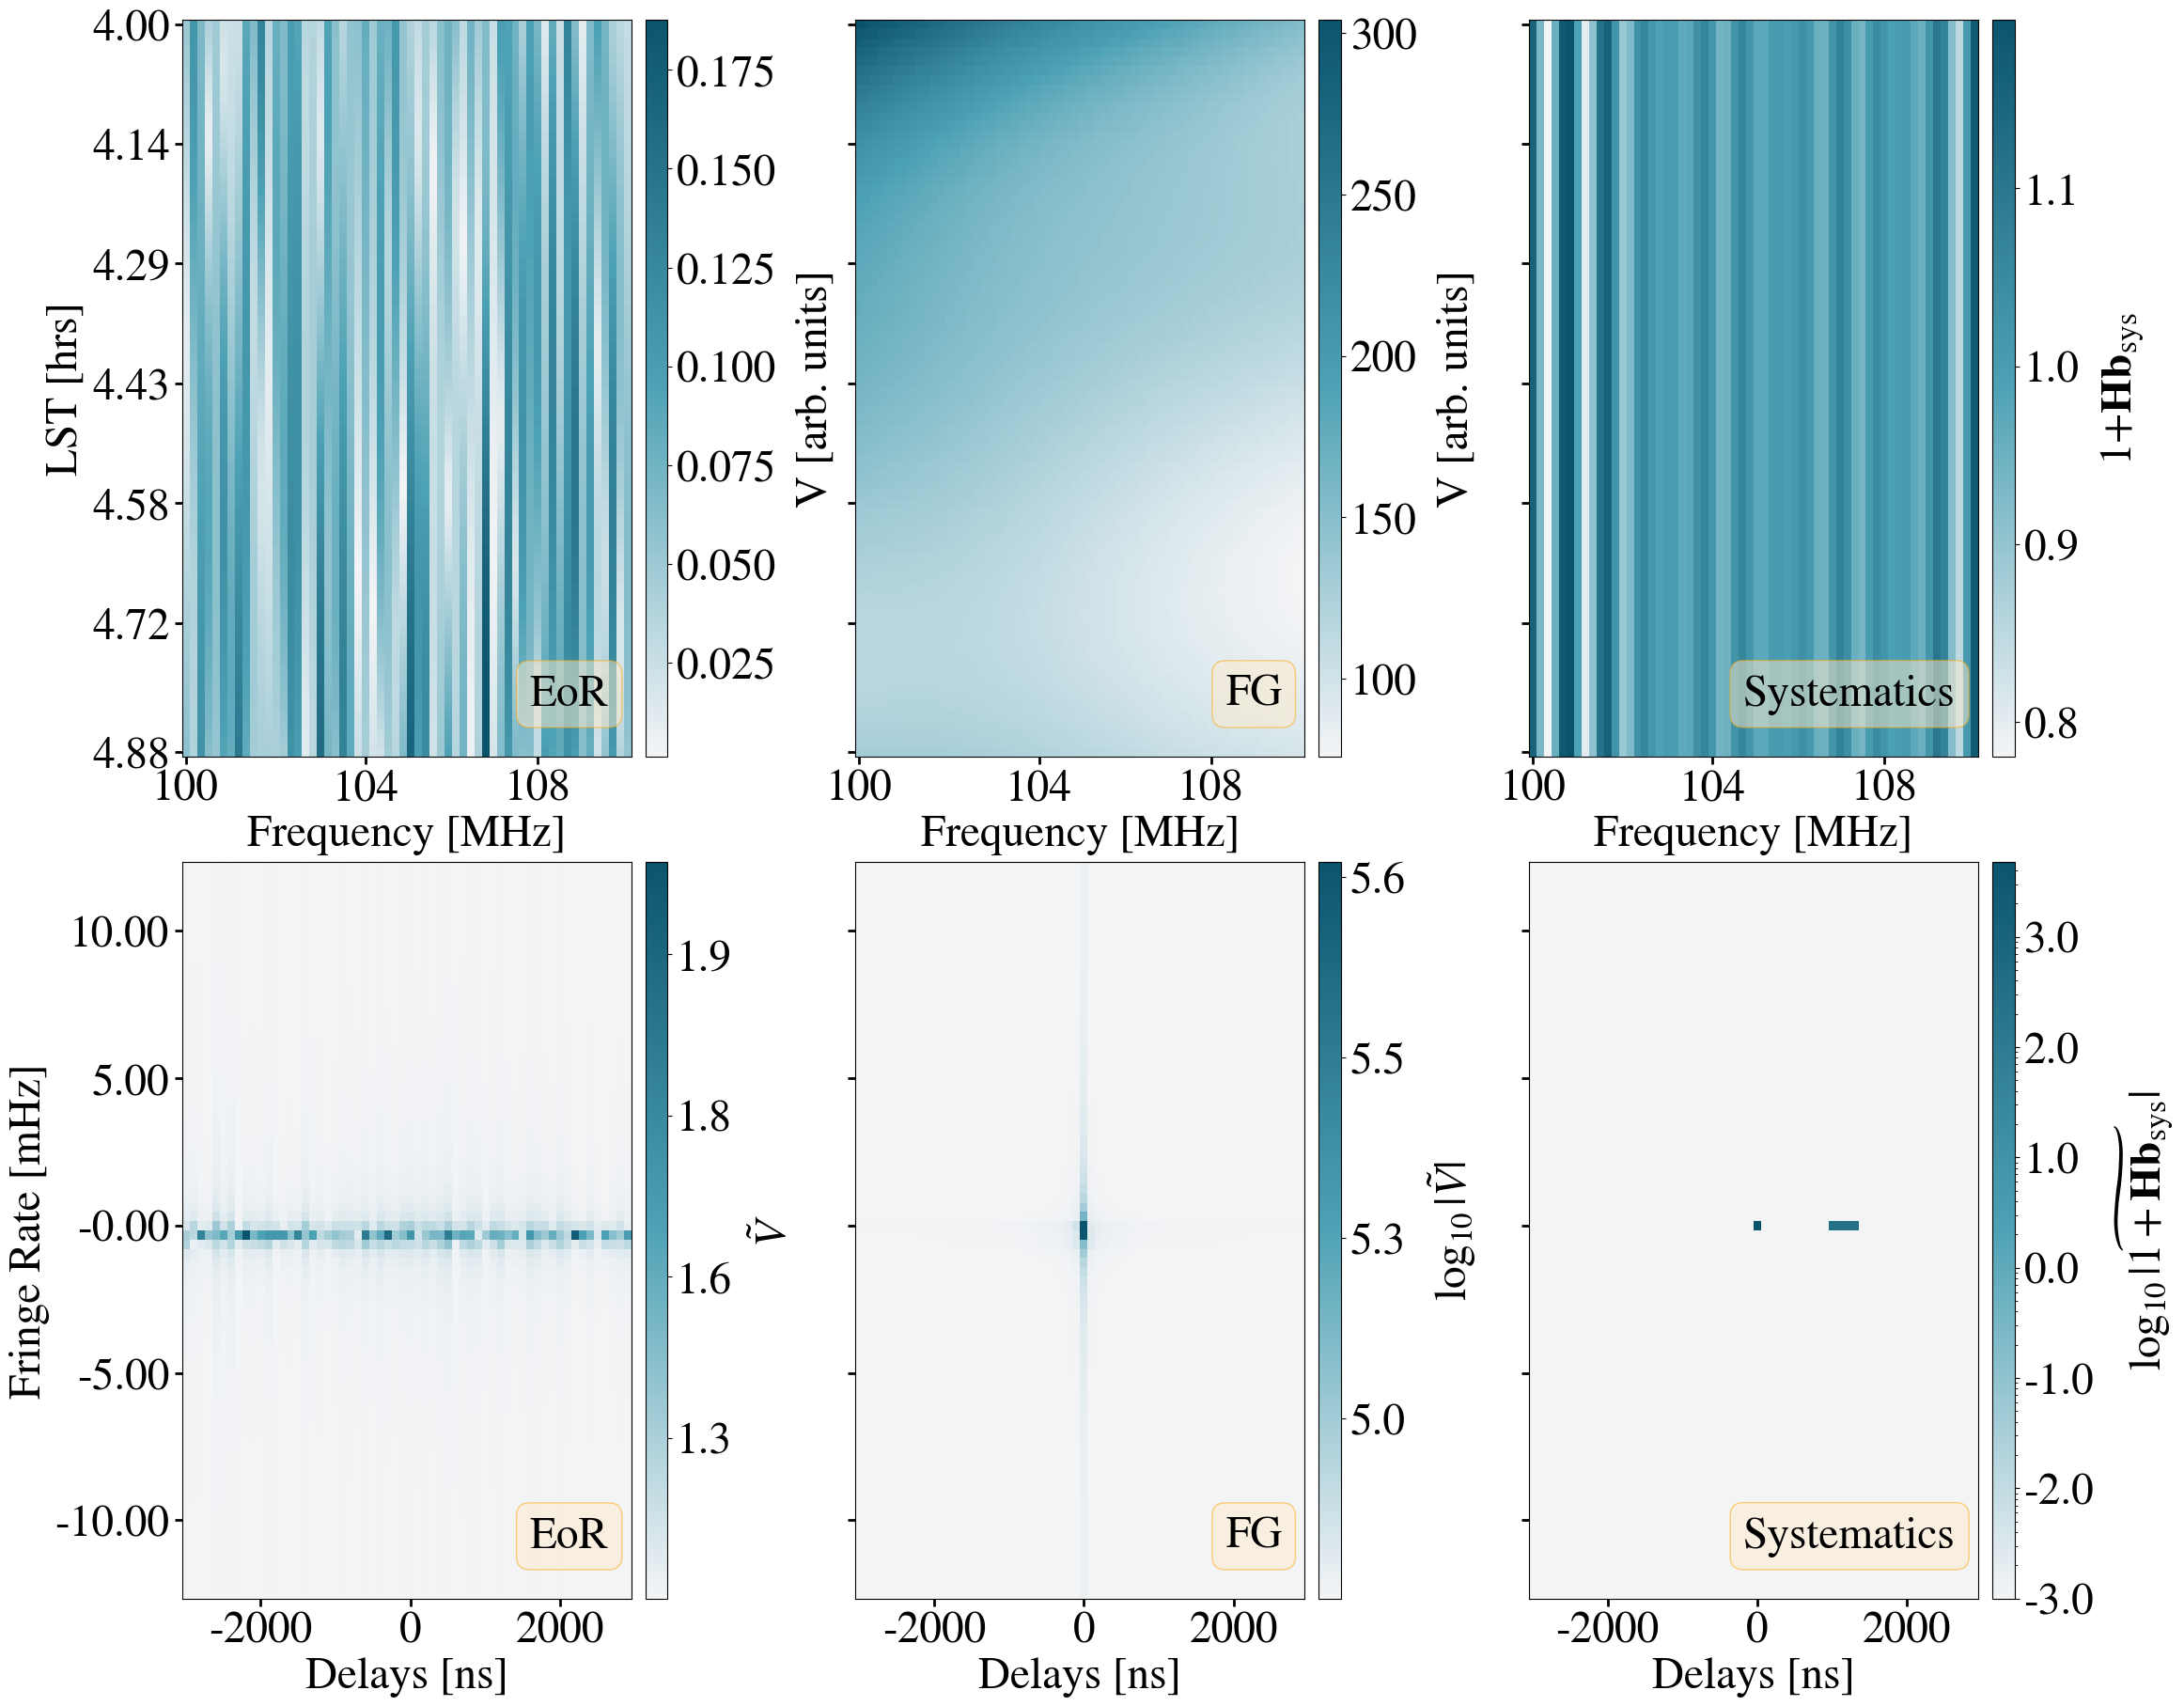

In [11]:
fig = plt.figure(figsize=(25., 28.))

log10_formatter = FuncFormatter(lambda val, pos: f'{np.log10(val):.1f}' if val > 0 else '')

grid_kwargs = dict(
    nrows_ncols = (1, 3),
    axes_pad    = 2.0,
    cbar_mode   = 'each',
    cbar_pad    = 0.15,
    cbar_size   = '5%',
    label_mode  = 'L',        # y-labels only on leftmost panel — avoids colorbar collision
    aspect      = False,
)

axs_top = ImageGrid(fig, rect=(0.06, 0.38, 0.78, 0.28), **grid_kwargs)
axs_bot = ImageGrid(fig, rect=(0.06, 0.06, 0.78, 0.28), **grid_kwargs)

cbar_labels_top = [r'V [arb. units]', r'V [arb. units]', r'1+$\mathbf{Hb}_\text{sys}$']
cbar_labels_bot = [r'$\tilde{V}$',    r'$\log_{10}|\tilde{V}|$',    r'$\log_{10}|\widetilde{1+\mathbf{Hb}}_\text{sys}|$']

# --- Plot top row ---
data_top = [eor_true, fg_true, 1+delta_g_true]
for ax, cbar_ax, label in zip(axs_top, axs_top.cbar_axes, cbar_labels_top):
    im = ax.imshow(np.abs(data_top.pop(0)), cmap=paper_map_blue, aspect='auto')  # aspect='auto' stops imshow overriding grid height
    cbar = plt.colorbar(im, cax=cbar_ax)           # pass cbar_ax directly — no make_axes_locatable needed
    cbar.set_label(label, fontsize=34, labelpad=15)
    cbar.ax.tick_params(which='both', color='black', labelcolor='black')
    ax.tick_params(direction='out', length=6, width=2, colors='black')

# --- Plot bottom row ---
data_bot = [compute_dlfr(eor_true,  freqs[:Nfreqs] * 1e6, times_jd[:Ntimes] * 24 / (2 * np.pi) * 3600, windows=None), compute_dlfr(fg_true,  freqs[:Nfreqs] * 1e6, times_jd[:Ntimes] * 24 / (2 * np.pi) * 3600, windows=None), dlfr_ones + delta_g_dlfr_true]
mode_bot = ['real','real','real']
i=0
for ax, cbar_ax, label in zip(axs_bot, axs_bot.cbar_axes, cbar_labels_bot):
    # im = plot_waterfalls_from_dlfr(
    #     data_dlfr     = data_bot.pop(0),
    #     freqs         = freqs[:Nfreqs] * 1e6,
    #     times         = times_jd[:Ntimes],
    #     fig           = fig,
    #     ax            = ax,
    #     colorbar_flag = False,
    #     windows       = None,
    #     cmap          = paper_map_blue,
    #     mode          = mode_bot.pop(0),
    #     ylab_flag     = False,
    # )
    im = ax.imshow(np.abs(data_bot.pop(0)), aspect='auto', cmap=paper_map_blue)  # aspect='auto' stops imshow overriding
    # Re-apply LogNorm so the colorbar ticks land at clean decades
    if i<2:
        cbar = plt.colorbar(im, cax=cbar_ax)
        cbar.set_label(label, fontsize=34, labelpad=15)
        cbar.ax.yaxis.set_major_formatter(log10_formatter)
        cbar.ax.tick_params(which='both', color='black', labelcolor='black')
        ax.tick_params(direction='out', length=6, width=2, colors='black')
    # elif i==1:
    #     vmin, vmax = im.get_clim()
    #     im.set_norm(mcolors.LogNorm(vmin=max(vmin, 1e-10), vmax=vmax))

    #     cbar = plt.colorbar(im, cax=cbar_ax)
    #     cbar.set_label(label, fontsize=34, labelpad=15)
    #     cbar.ax.yaxis.set_major_formatter(log10_formatter)
    #     cbar.ax.tick_params(which='both', color='black', labelcolor='black')
    #     ax.tick_params(direction='out', length=6, width=2, colors='black')
    elif i==2:
        vmin, vmax = im.get_clim()
        im.set_norm(mcolors.LogNorm(vmin=max(vmin, 1e-3), vmax=vmax))

        cbar = plt.colorbar(im, cax=cbar_ax)
        cbar.set_label(label, fontsize=34, labelpad=15)
        cbar.ax.yaxis.set_major_formatter(log10_formatter)
        cbar.ax.tick_params(which='both', color='black', labelcolor='black')
        ax.tick_params(direction='out', length=6, width=2, colors='black')
    i=i+1

# --- Ticks top ---
for ax in axs_top:
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xticks(xticklocs_freq, labels=xticklabels_freqs)
    ax.set_yticks(yticklocs_time[::-1], labels=yticklabels_times[::-1])
    ax.set_xlim(x0, x1)        # restore — pixel-index ticks expand limits without this
    ax.set_ylim(y0, y1)
    ax.set_xlabel("Frequency [MHz]")

# --- Ticks bottom ---
for ax in axs_bot:
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xticks(xticklocs_dl, labels=xticklabels_dl)
    ax.set_yticks(yticklocs_fr, labels=yticklabels_fr)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.invert_yaxis()
    ax.set_xlabel("Delays [ns]")

axs_top[0].set_ylabel("LST [hrs]")
axs_bot[0].set_ylabel("Fringe Rate [mHz]")

bbox_labels = ['EoR', 'FG', 'Systematics']
for ax, label in zip(axs_top, bbox_labels):
    ax.text(0.95, 0.07, label, bbox=bbox, transform=ax.transAxes, horizontalalignment='right')
for ax, label in zip(axs_bot, bbox_labels):
    ax.text(0.95, 0.07, label, bbox=bbox, transform=ax.transAxes, horizontalalignment='right')

plt.savefig(fig_dir + '/data_components.pdf', bbox_inches='tight', dpi=300)
print("Data components saved, (1/10)")

---
# Figure 2 (fig:test_data_dlfr): Test cases in delay–fringe-rate space → test_cases_in_dlfr.pdf

In [12]:
from astropy import constants, units
from uvtools.plot import waterfall

def plot_waterfalls_from_dlfr(data_dlfr, freqs, times, mode='log', fig=None, ax=None, xlabel=None,
                               vmin=None, vmax=None, cmap='inferno', dynamic_range=None, limit_drng='all',
                               ylab_flag=True,
                               baseline=None, horizon_color='magenta', plot_limits=None,
                               colorbar_flag=True, cbar_label=None):
    """
    Plot pre-computed delay–fringe-rate data as a waterfall image.

    Equivalent to ``plot_waterfalls`` but accepts data that has already been
    transformed to the delay–fringe-rate domain, skipping the FFT step.

    Parameters
    ----------
    data_dlfr : ndarray, shape=(Ntimes, Nfreqs)
        Visibility data already in delay–fringe-rate space.
    freqs : ndarray, shape=(Nfreqs,)
        Observed frequencies in Hz (used to derive the delay axis).
    times : ndarray, shape=(Ntimes,)
        Observed times in JD (used to derive the fringe-rate axis).
    mode : str, optional
        Plot mode passed to ``uvtools.plot.waterfall``. Default: 'log'.
    fig, ax : optional
        Figure/axes to plot into; created if not provided.
    xlabel : str, optional
        Label for the x-axis. Default: "Delay [ns]".
    vmin, vmax : float, optional
        Color scale limits.
    cmap : str or Colormap, optional
        Colormap. Default: 'inferno'.
    dynamic_range : float, optional
        Orders of magnitude for the color range when ``mode='log'``.
    limit_drng : str or sequence, optional
        Domains for which to apply dynamic-range clipping. Default: 'all'.
    baseline : float or array-like, optional
        Baseline length in metres for geometric horizon lines.
    horizon_color : str or tuple, optional
        Color for horizon lines. Default: 'magenta'.
    plot_limits : dict, optional
        Axis limit overrides, e.g. ``{'delay': (-500, 500)}``.
    colorbar_flag : bool, optional
        Whether to draw a colorbar. Default: True.
    cbar_label : str, optional
        Override for the colorbar label. For ``mode='log'``, the default
        label is the standard visibility units string. For ``mode='abs'``,
        the default is "Amplitude [Jy Hz s]".

    Returns
    -------
    cax : matplotlib.image.AxesImage
        Return value of the waterfall call.
    """
    fringe_rates = fourier_freqs(times * units.day.to('s')) * 1e3  # mHz
    dlys = fourier_freqs(freqs) * 1e9  # ns
    jd = int(np.floor(times[0]))

    if baseline is not None:
        horizon = np.linalg.norm(baseline) / constants.c.value * 1e9  # ns

    if ax is None:
        fig = plt.figure(figsize=(10, 10), facecolor='white')
        ax = fig.subplots(1, 1)

    ax.set_facecolor('white')
    ax.tick_params(direction='out', length=6, width=2, colors='black')

    if xlabel is None:
        xlabel = "Delay [ns]"
    ax.set_xlabel(xlabel, color='black')
    if ylab_flag:
        ax.set_ylabel("Fringe Rate [mHz]", color='black')

    extent = (dlys.min(), dlys.max(), fringe_rates.max(), fringe_rates.min())
    xlimits, ylimits = extent[:2], extent[2:]
    if plot_limits is not None:
        xlimits = plot_limits.get("delay", xlimits)
        ylimits = plot_limits.get("fringe_rate", ylimits)

    # Dynamic range clipping
    if limit_drng == 'all':
        limit_drng = ("freq", "time", "delay", "fringe_rate")
    clip_drng = ("freq" in limit_drng) or ("fringe_rate" in limit_drng)

    if clip_drng and dynamic_range is not None and mode == 'log':
        if vmax is None:
            vmax = np.log10(np.abs(data_dlfr)).max()
        if vmin is None:
            vmin = vmax - dynamic_range
    elif not clip_drng:
        vmin, vmax = None, None

    # Determine colorbar label
    vis_label = r"$\log_{10}|\tilde{V}(\tau, f)|$ [Jy Hz s]"
    if cbar_label is None:
        if mode == 'log':
            cbar_label = vis_label
        elif mode == 'phs':
            cbar_label = "Phase [rad]"
        else:
            cbar_label = "Amplitude [Jy Hz s]"
    elif mode == 'log':
        # Append units label to caller-supplied prefix
        cbar_label = cbar_label + ' ' + vis_label

    fig.sca(ax)
    cax = waterfall(data_dlfr, extent=extent, mode=mode, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xlim(xlimits)
    ax.set_ylim(ylimits)

    if baseline is not None:
        ax.axvline(horizon, color=horizon_color, ls='--')
        ax.axvline(-horizon, color=horizon_color, ls='--')

    if colorbar_flag:
        cb = plt.colorbar(cax)
        cb.set_label(cbar_label, c='black')
        cb.ax.tick_params(axis='y', which='both', color='black', labelcolor='black')

    return cax

log10_formatter = FuncFormatter(lambda val, pos: f'{np.log10(val):.1f}' if val > 0 else '')


IndexError: list index out of range

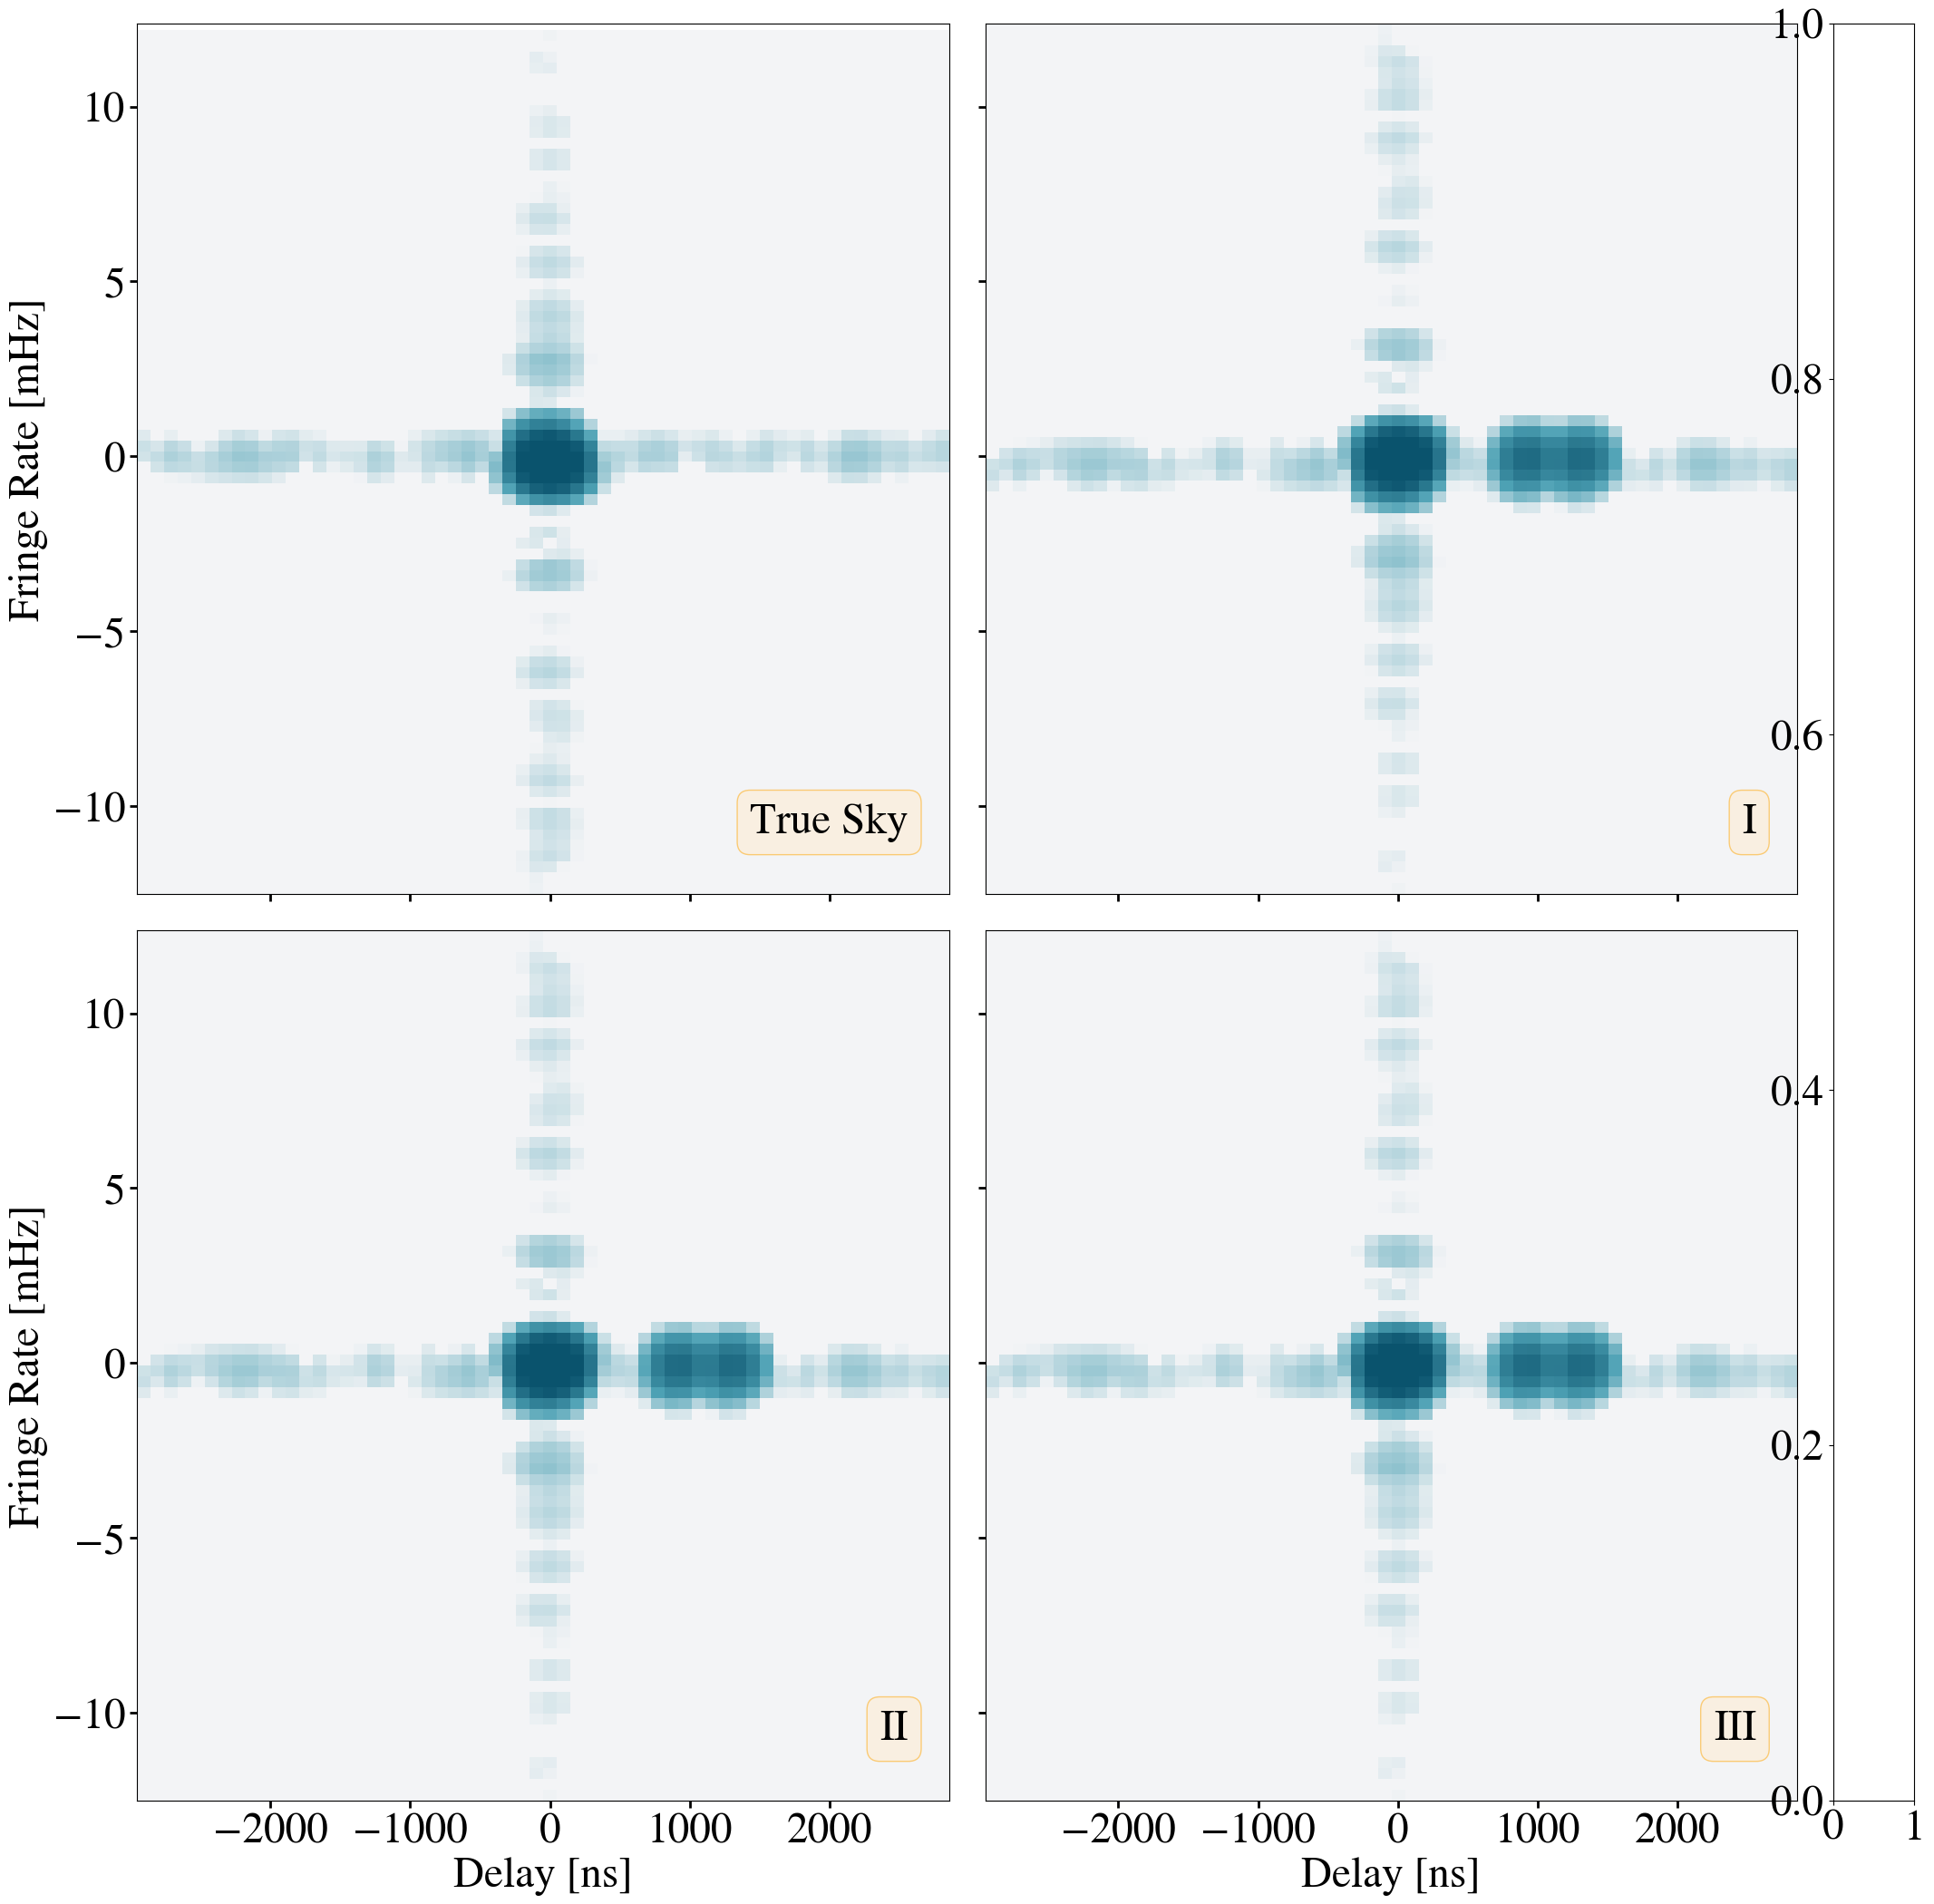

In [13]:
fig = plt.figure(figsize=(20., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.98, 0.98),
    nrows_ncols=(2, 2),
    axes_pad=0.4,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='L',
    aspect=False,
)

_ = plot_waterfalls(
    eor_true+fg_true, freqs[:Nfreqs] * 1e6, times_jd[:Ntimes], fig=fig, ax=axs[0], mode='log', windows='blackman-harris',vmin=0,vmax=4,
    baseline=None, horizon_color='magenta', colorbar_flag=False, cmap=paper_map_blue
)
axs[0].text(0.95, 0.07, 'True Sky', bbox=bbox, transform=axs[0].transAxes, horizontalalignment='right')

fig_labels = ['I', 'II', 'III']
for i, run_version in enumerate(run_version_arr):
    sys_model_true = np.load(result_dir + run_version + '/gain_true.npy')
    # op = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts_sec, modes=nm_list_arr[i])
    # sys_model_true = (1 + op @ sys_amps_true).reshape((Nfreqs, Ntimes)).T
    total_data_dlfr = dlfr(sys_model_true * (eor_true+fg_true))
    plot_op = plot_waterfalls_from_dlfr(
        total_data_dlfr, freqs * 1e6, times_jd, fig=fig, ax=axs[i + 1], mode='log',
        vmin=0, vmax=4, cmap=paper_map_blue, dynamic_range=5, limit_drng='all', colorbar_flag=False,
        baseline=None, horizon_color='magenta',
    )
    axs[i + 1].text(0.95, 0.07, fig_labels[i], bbox=bbox, transform=axs[i + 1].transAxes, horizontalalignment='right')
    axs[i + 1].invert_yaxis()  # flip so -ve fringe rates at the bottom
axs.cbar_axes[0].colorbar(plot_op, label=r'$\log_{10}|\tilde{V}|$')
for a in axs:
    a.axvline(dl_zero, color=colors[0], linestyle='--', linewidth=1)
    a.axhline(0, color=colors[0], linestyle='--', linewidth=1)
# plt.savefig(fig_dir + '/test_cases_in_dlfr.pdf', bbox_inches='tight', dpi=300)
print("Test cases in delay-fringe-rate space saved, (2/10)")

---
# [COMMENTED OUT in tex] Data vs sky (all cases) → data_vs_sky_2.pdf

---
# Figures 3 & 5 (fig:result_waterfalls, fig:result_sys_waterfalls): All-cases result waterfalls

Versions of Figures 5 and 6 with all three cases shown simultaneously.
Columns = Case I / II / III; Rows = True / Mean / Std / Residuals.

In [13]:
# All-cases statistics for the v2 figures were computed in the "All-cases data" cell above.
# Lists are indexed 0/1/2 = Case I / II / III.
# Available: sky_true_dlfr_all, mean_sky_dlfr_all, std_sky_dlfr_all, res_sky_dlfr_all,
#            delta_g_dlfr_true_all, delta_g_dlfr_mean_all, delta_g_dlfr_std_all, res_sys_dlfr_all.

case_labels_v2 = case_labels
row_labels_v2  = ['Fringe Rate [mHz]', 'Fringe Rate [mHz]','Fringe Rate [mHz]','Fringe Rate [mHz]']
annots_sky_v2  = ['True Sky Visibilities', r'$\mu$', r'$\sigma$', r'Residuals (True - $\mu$)']

### Figure 3 (fig:result_waterfalls): Sky result waterfalls (all cases) → result_waterfalls_v2.pdf

### Figure 5 (fig:result_sys_waterfalls): Systematics result waterfalls (all cases) → sys_result_dlfr_waterfalls_v2.pdf

Systematics result waterfalls (all cases) saved, (5/10)


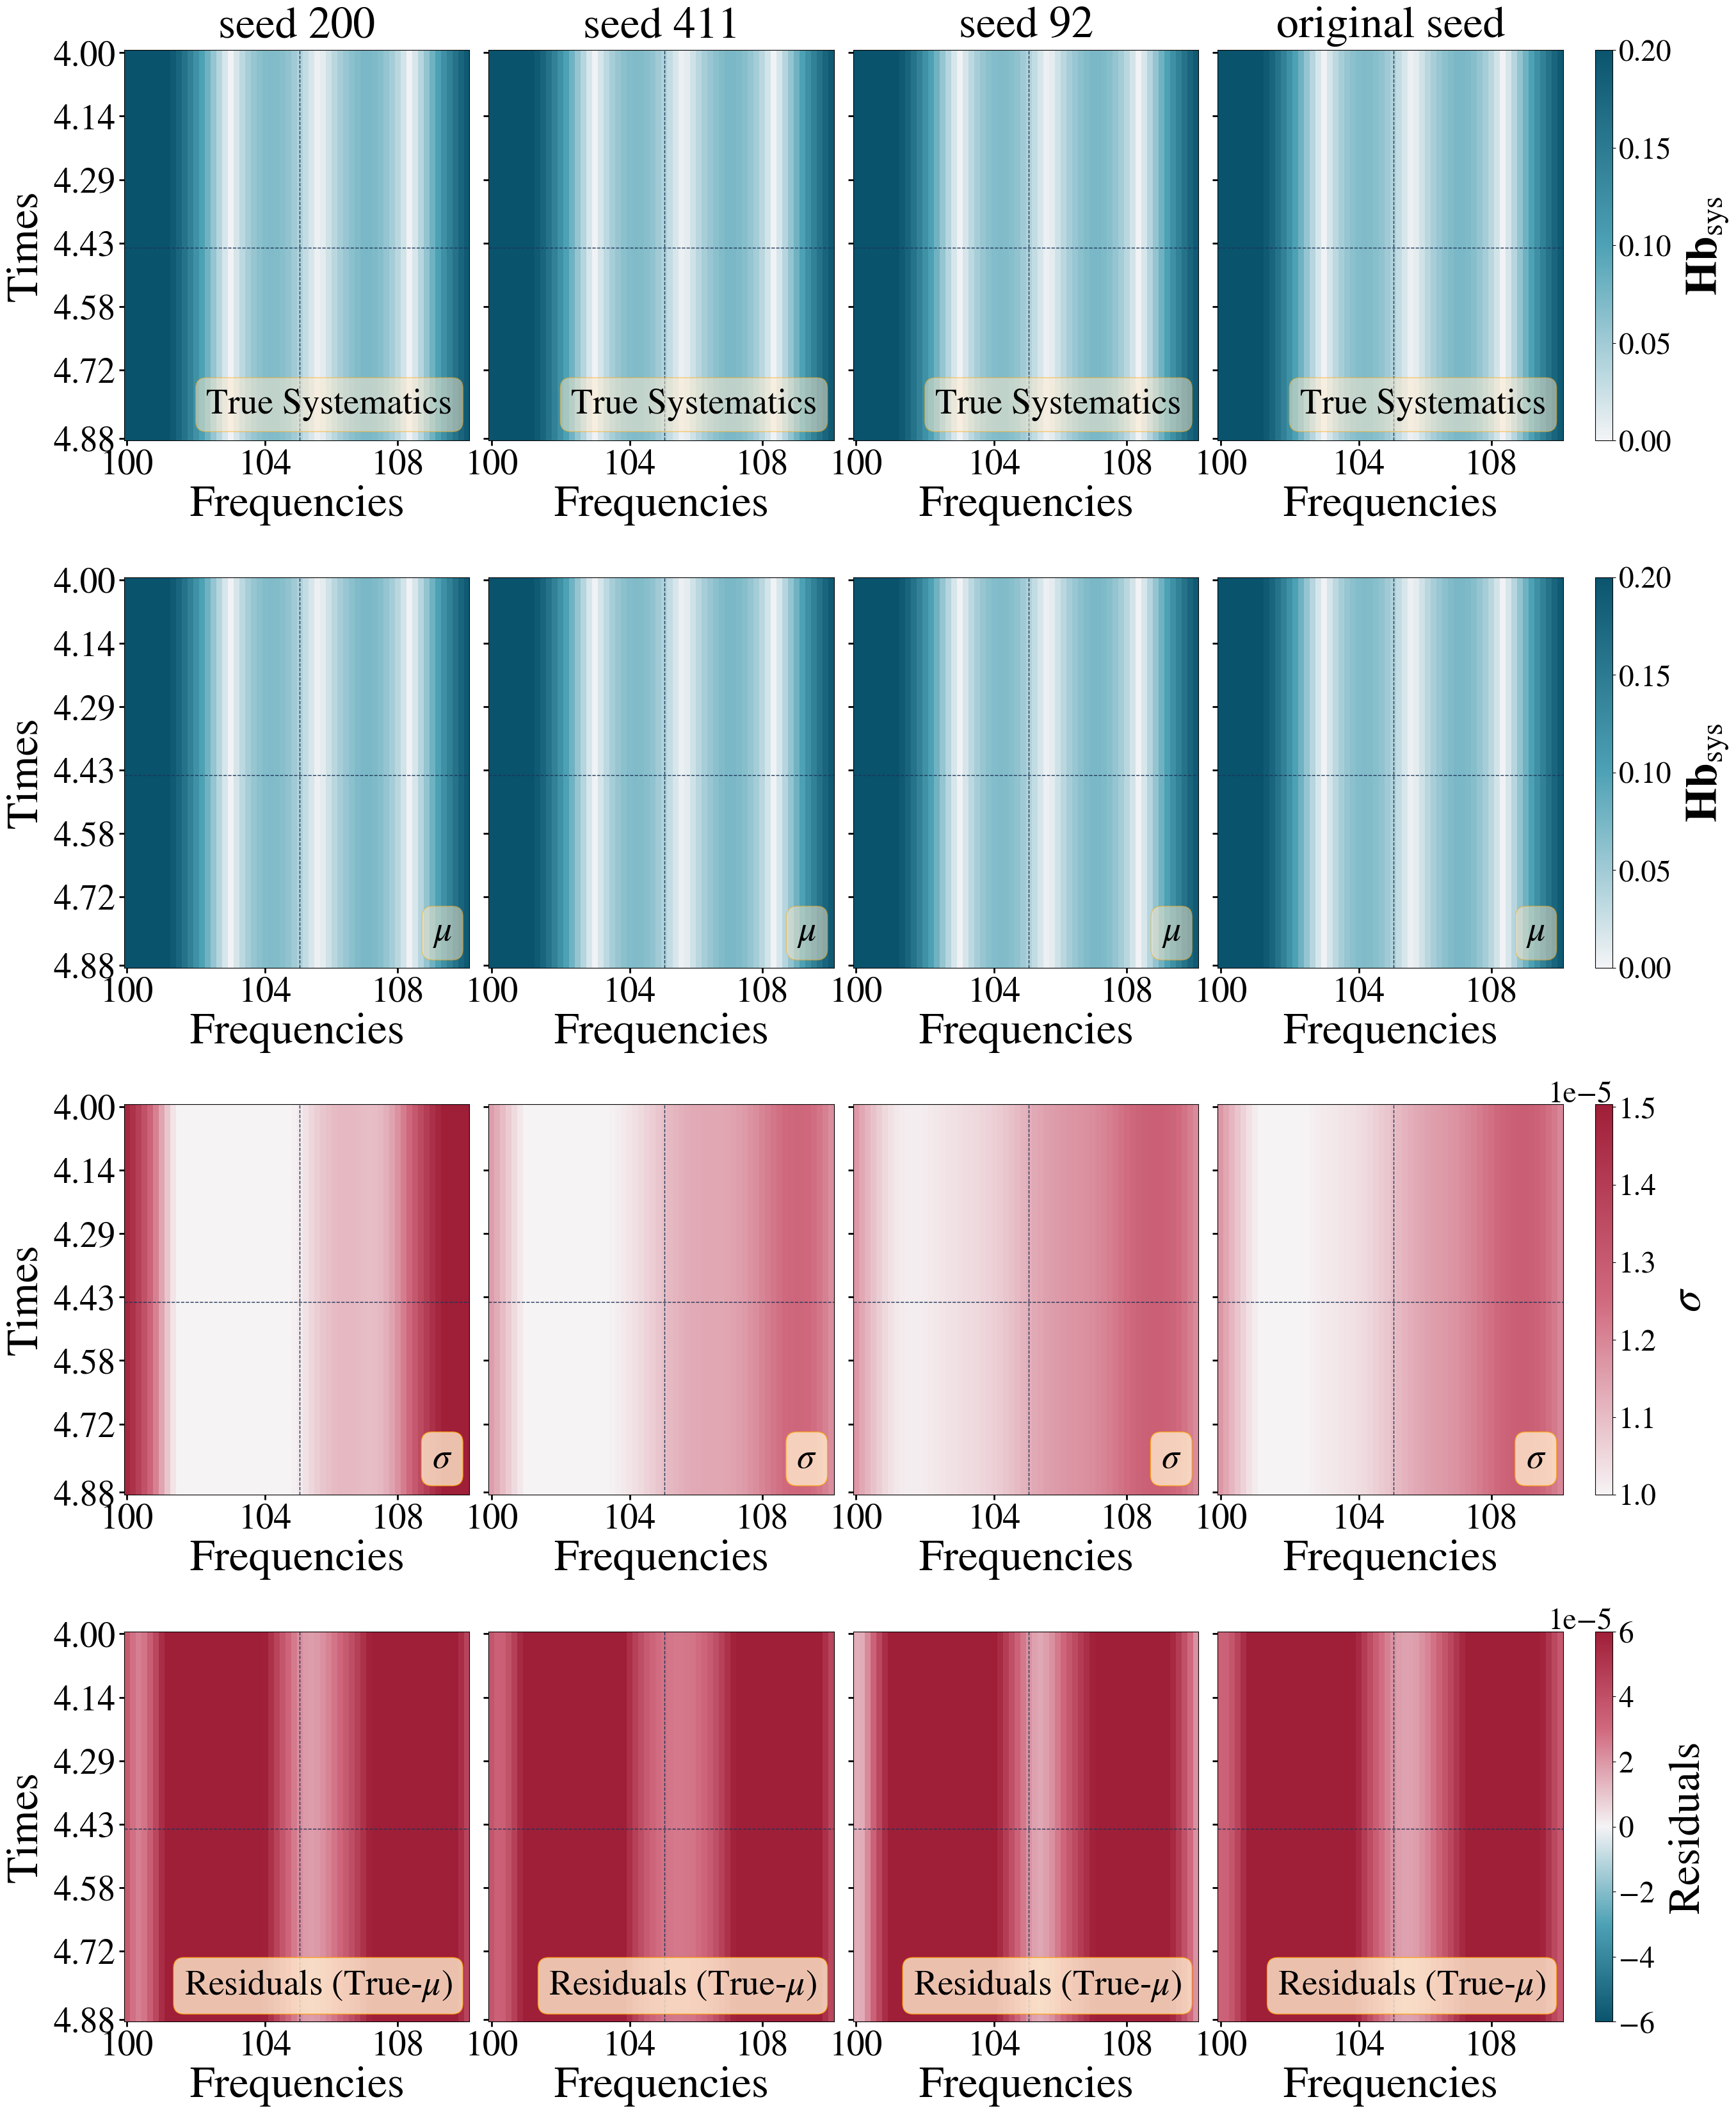

In [23]:
annots_sys_v2 = [
    'True Systematics',
    r'$\mu$',
    r'$\sigma$',
    'Residuals (True-' + r'$\mu$' + ')',
]

fig6v2 = plt.figure(figsize=(30, 40))
outer_gs = gridspec.GridSpec(4, 1, figure=fig6v2, hspace=0.35)

grids = []
for row in range(4):
    grid = ImageGrid(
        fig6v2, outer_gs[row],
        nrows_ncols=(1, case_num),
        axes_pad=0.3,
        share_all=True,
        cbar_location='right',
        cbar_mode='single',
        cbar_size='5%',
        cbar_pad=0.5,
        aspect=False,
    )
    grids.append(grid)

cmap_list  = [paper_map_blue, paper_map_blue, paper_map_pink, paper_map]
# mode_list  = ['abs', 'abs', 'abs', 'real']
mode_list = ['abs', 'abs', 'abs', 'abs']
vmin_list  = [0, 0, 1e-5, -6e-5]
vmax_list  = [0.2, 0.2, None,  6e-5]
cbar_labels = [
    r'$\mathbf{Hb}_\mathrm{sys}$',
    r'$\mathbf{Hb}_\mathrm{sys}$',
    r'$\sigma$',
    'Residuals',
]
data_all = [
    delta_g_true_all,
    delta_g_mean_all,
    delta_g_std_all,
    # res_sys_dlfr_all,
    (np.array(delta_g_true_all) - np.array(delta_g_mean_all)).tolist()
]

for row, grid in enumerate(grids):
    cmap = cmap_list[row]
    mode = mode_list[row]

    # --- Per-row data transform ---
    if mode == 'real':
        row_data = [np.real(data_all[row][col]) for col in range(case_num)]
    else:
        row_data = [np.abs(data_all[row][col]) for col in range(case_num)]

    # --- Per-row shared vmin/vmax ---
    if vmin_list[row] is None or vmax_list[row] is None:
        all_vals = np.concatenate([d.ravel() for d in row_data])
        vmin = all_vals.mean() - 0.25*np.abs(all_vals.min()) if vmin_list[row] is None else vmin_list[row]
        vmax = all_vals.mean() + 0.25*np.abs(all_vals.max()) if vmax_list[row] is None else vmax_list[row]
    else:
        vmin = vmin_list[row]
        vmax = vmax_list[row]

    im = None
    for col in range(case_num):
        im = grid[col].imshow(
            row_data[col],
            aspect='auto',
            cmap=cmap, vmin=vmin, vmax=vmax,
        )
        grid[col].invert_yaxis()
        grid[col].tick_params(direction='out', length=6, width=2, colors='black', labelsize=40)
        x0, x1 = grid[col].get_xlim()
        y0, y1 = grid[col].get_ylim()
        grid[col].set_xticks(xticklocs_freq, labels=xticklabels_freqs)
        grid[col].set_yticks(yticklocs_time, labels=yticklabels_times)
        grid[col].set_xlim(x0, x1)
        grid[col].set_ylim(y0, y1)
        grid[col].axvline(dl_zero, color=colors[0], linestyle='--', linewidth=1)
        grid[col].axhline(fr_zero, color=colors[0], linestyle='--', linewidth=1)

        bbox_use = bbox_res if row >= 2 else bbox
        grid[col].text(
            0.95, 0.07, annots_sys_v2[row], bbox=bbox_use,
            transform=grid[col].transAxes, ha='right', fontsize=40,
        )
        if row == 0:
            grid[col].set_title(case_labels_v2[col], fontsize=50, pad=15)
        grid[col].set_xlabel('Frequencies', fontsize=50)

    # --- Shared colorbar with log10 labels for amplitude rows ---
    cbar = grid.cbar_axes[0].colorbar(im)
    cbar.set_label(cbar_labels[row], fontsize=50, labelpad=15)
    # if row<2:
    #     cbar.ax.yaxis.set_major_formatter(log10_formatter)
    # cbar.ax.tick_params(which='both', color='black', labelcolor='black', labelsize=40)

    grid[0].set_ylabel('Times', fontsize=50, labelpad=8)

# plt.savefig(fig_dir + '/sys_result_dlfr_waterfalls_v2.pdf', bbox_inches='tight', dpi=300)
print("Systematics result waterfalls (all cases) saved, (5/10)")

In [58]:
np.array(data_all[0][-1]).shape

(80, 60)

In [60]:
res_flattened = np.array(data_all[0][-1]).flatten(order='F')

In [25]:
def fit_residuals_to_operator(operator, residuals, fit_offset=True, mask_nan=True):
    """
    Fit residuals to a projection operator, column by column, using
    complex-valued linear least squares.

    For each column j, solves:
        residuals[:, j] ≈ a_j * operator[:, j] + b_j   (if fit_offset=True)
        residuals[:, j] ≈ a_j * operator[:, j]          (if fit_offset=False)
    for the complex scalar(s) a_j (and b_j).

    Parameters
    ----------
    operator : ndarray, shape (N, M), complex
        The projection operator / design matrix.
    residuals : ndarray, shape (N, M), complex
        The residuals to fit, same shape as operator.
    fit_offset : bool
        If True, fit an additive complex offset per column as well as a
        scale factor. If False, pure projection (scale only).
    mask_nan : bool
        If True, drop NaN entries per column before fitting (handles
        flagged/masked data without needing to pre-clean the whole array).

    Returns
    -------
    dict with:
        'scale'    : ndarray, shape (M,), complex — fitted a_j per column
        'offset'   : ndarray, shape (M,), complex — fitted b_j per column
                     (zeros if fit_offset=False)
        'residual' : ndarray, shape (N, M), complex — data minus fit
                     (NaN preserved where masked)
        'chi2'     : ndarray, shape (M,), float — sum |fit residual|^2 per column
        'rank'     : ndarray, shape (M,), int — lstsq-reported rank per column
                     (rank < expected → operator column is degenerate for
                     that fit, worth flagging rather than trusting the result)
    """
    operator = np.asarray(operator, dtype=complex)
    residuals = np.asarray(residuals, dtype=complex)
    assert operator.shape == residuals.shape, "operator and residuals must match shape"

    N, M = operator.shape
    scale = np.zeros(M, dtype=complex)
    offset = np.zeros(M, dtype=complex)
    fit_resid = np.full((N, M), np.nan, dtype=complex)
    chi2 = np.zeros(M)
    rank = np.zeros(M, dtype=int)

    for j in range(M):
        op_col = operator[:, j]
        data_col = residuals[:, j]

        if mask_nan:
            good = ~(np.isnan(op_col) | np.isnan(data_col))
        else:
            good = np.ones(N, dtype=bool)

        if good.sum() < (2 if fit_offset else 1):
            # Not enough valid points to fit — leave as NaN, don't silently
            # return a meaningless zero fit
            scale[j] = np.nan
            offset[j] = np.nan if fit_offset else 0.0
            chi2[j] = np.nan
            rank[j] = 0
            continue

        op_g = op_col[good]
        data_g = data_col[good]

        if fit_offset:
            A = np.column_stack([op_g, np.ones_like(op_g)])
        else:
            A = op_g[:, None]

        coeffs, res, r, sv = np.linalg.lstsq(A, data_g, rcond=None)

        scale[j] = coeffs[0]
        offset[j] = coeffs[1] if fit_offset else 0.0
        rank[j] = r

        model_g = A @ coeffs
        resid_g = data_g - model_g
        fit_resid[good, j] = resid_g
        chi2[j] = np.sum(np.abs(resid_g) ** 2)

    return {
        'scale': scale,
        'offset': offset,
        'residual': fit_resid,
        'chi2': chi2,
        'rank': rank,
    }

In [31]:
fitting_vals = fit_residuals_to_operator(sys_modes_operator, res_flattened, fit_offset = False)

              |scale|   arg(scale)   |offset|  arg(offset)         chi2   rank
------------------------------------------------------------------------------
col 0         0.06878       77.90°          0        0.00°        581.4      1
col 1          0.1031       92.96°          0        0.00°        553.9      1
col 2          0.1127      151.06°          0        0.00°        776.8      1
col 3         0.02733      -41.97°          0        0.00°        558.9      1


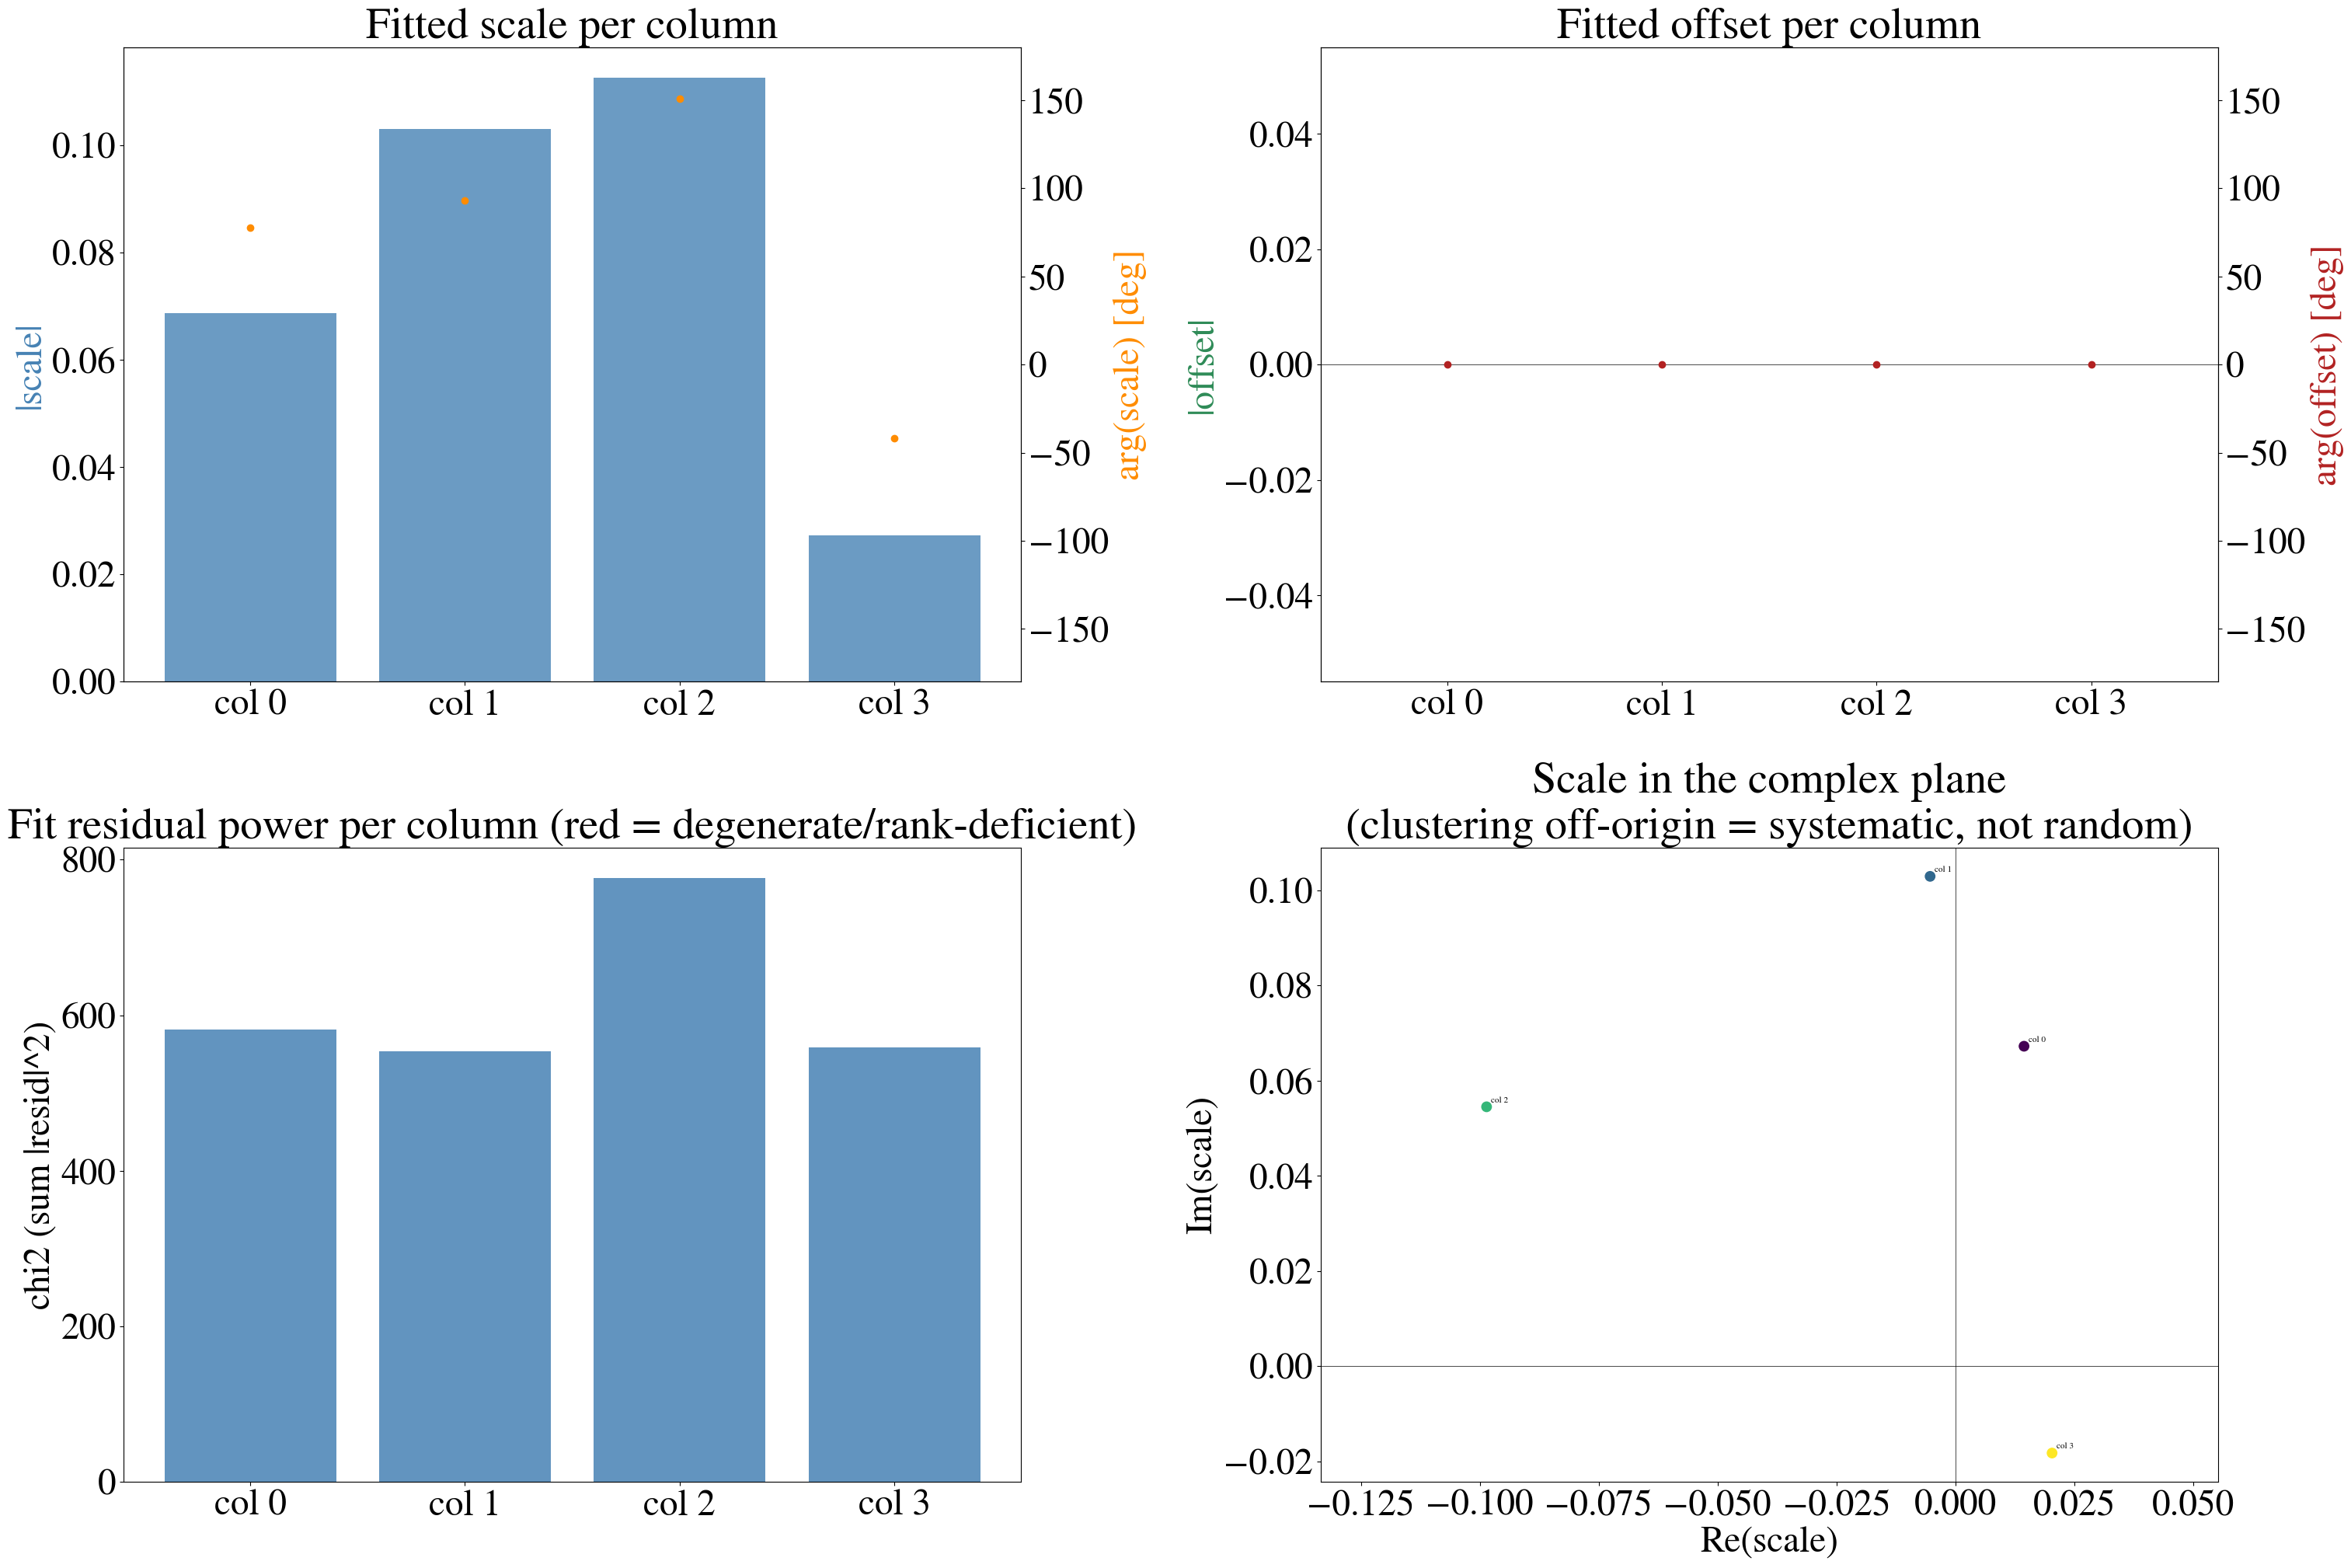

In [34]:
def print_fit_summary(fit_result, labels=None):
    """
    Pretty-print scale/offset/chi2/rank per column, complex values shown
    as magnitude + phase (more interpretable than raw real/imag for
    spotting systematic bias).
    """
    M = len(fit_result['scale'])
    if labels is None:
        labels = [f"col {j}" for j in range(M)]

    expected_rank = 2 if np.any(fit_result['offset'] != 0) else 1

    header = f"{'':10s} {'|scale|':>10s} {'arg(scale)':>12s} {'|offset|':>10s} {'arg(offset)':>12s} {'chi2':>12s} {'rank':>6s}"
    print(header)
    print("-" * len(header))
    for j in range(M):
        s, o, c2, r = fit_result['scale'][j], fit_result['offset'][j], fit_result['chi2'][j], fit_result['rank'][j]
        flag = "  <-- degenerate!" if r < expected_rank else ""
        print(f"{labels[j]:10s} {np.abs(s):10.4g} {np.degrees(np.angle(s)):11.2f}° "
              f"{np.abs(o):10.4g} {np.degrees(np.angle(o)):11.2f}° {c2:12.4g} {r:6d}{flag}")


def plot_fit_results(fit_result, labels=None, figsize=(31, 21)):
    """
    Four-panel overview: scale (mag+phase), offset (mag+phase), chi2 per
    column, and a real-vs-imaginary scatter of scale to check whether the
    bias direction is consistent across columns (a strong visual tell for
    a systematic vs. random effect).
    """
    scale = fit_result['scale']
    offset = fit_result['offset']
    chi2 = fit_result['chi2']
    rank = fit_result['rank']
    M = len(scale)
    if labels is None:
        labels = [f"col {j}" for j in range(M)]
    x = np.arange(M)

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # Panel 1: scale, magnitude + phase
    ax = axes[0, 0]
    ax.bar(x, np.abs(scale), color='steelblue', alpha=0.8, label='|scale|')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel('|scale|', color='steelblue')
    ax.axhline(0, color='k', lw=0.5)
    ax2 = ax.twinx()
    ax2.scatter(x, np.degrees(np.angle(scale)), color='darkorange', zorder=5, label='arg(scale)')
    ax2.set_ylabel('arg(scale) [deg]', color='darkorange')
    ax2.set_ylim(-180, 180)
    ax.set_title('Fitted scale per column')

    # Panel 2: offset, magnitude + phase
    ax = axes[0, 1]
    ax.bar(x, np.abs(offset), color='seagreen', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel('|offset|', color='seagreen')
    ax.axhline(0, color='k', lw=0.5)
    ax2 = ax.twinx()
    ax2.scatter(x, np.degrees(np.angle(offset)), color='firebrick', zorder=5)
    ax2.set_ylabel('arg(offset) [deg]', color='firebrick')
    ax2.set_ylim(-180, 180)
    ax.set_title('Fitted offset per column')

    # Panel 3: chi2 per column, flag degenerate fits
    ax = axes[1, 0]
    expected_rank = 2 if np.any(offset != 0) else 1
    colors = ['crimson' if r < expected_rank else 'steelblue' for r in rank]
    ax.bar(x, chi2, color=colors, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel('chi2 (sum |resid|^2)')
    ax.set_title('Fit residual power per column (red = degenerate/rank-deficient)')

    # Panel 4: scale in the complex plane — a systematic bias clusters
    # in one direction; random noise scatters roughly isotropically
    ax = axes[1, 1]
    ax.scatter(scale.real, scale.imag, c=x, cmap='viridis', s=80, zorder=5)
    for j in range(M):
        ax.annotate(labels[j], (scale.real[j], scale.imag[j]), fontsize=8,
                    xytext=(4, 4), textcoords='offset points')
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('Re(scale)')
    ax.set_ylabel('Im(scale)')
    ax.set_title('Scale in the complex plane\n(clustering off-origin = systematic, not random)')
    ax.set_aspect('equal', adjustable='datalim')

    plt.tight_layout()
    return fig


# Usage:
print_fit_summary(fitting_vals)
fig = plot_fit_results(fitting_vals)
plt.show()

In [78]:
def fit_and_score(operator, residual):
    """
    Fits residual = c0*operator[:,0] + c1*operator[:,1] + c2*operator[:,2] + c3*operator[:,3]
    i.e. finds the best combination of the 4 operator columns that explains
    the single residual vector.

    operator : (4800, 4) complex
    residual : (4800,)   complex
    """
    coeffs, _, _, _ = np.linalg.lstsq(operator, residual, rcond=None)

    predicted = operator @ coeffs
    goodness = 1 - np.sum(np.abs(residual - predicted)**2) / np.sum(np.abs(residual)**2)

    return coeffs, goodness


def plot_fit(operator, residual, coeffs):
    """Single measured-vs-predicted plot for the joint fit."""
    predicted = operator @ coeffs

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(predicted.real, residual.real, s=8, alpha=0.4)
    lims = [residual.real.min(), residual.real.max()]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel('predicted')
    ax.set_xlim(-0.1,0.1)
    ax.set_ylabel('measured')
    ax.set_title('Joint fit: residual vs. H @ coeffs')

    plt.tight_layout()
    return fig

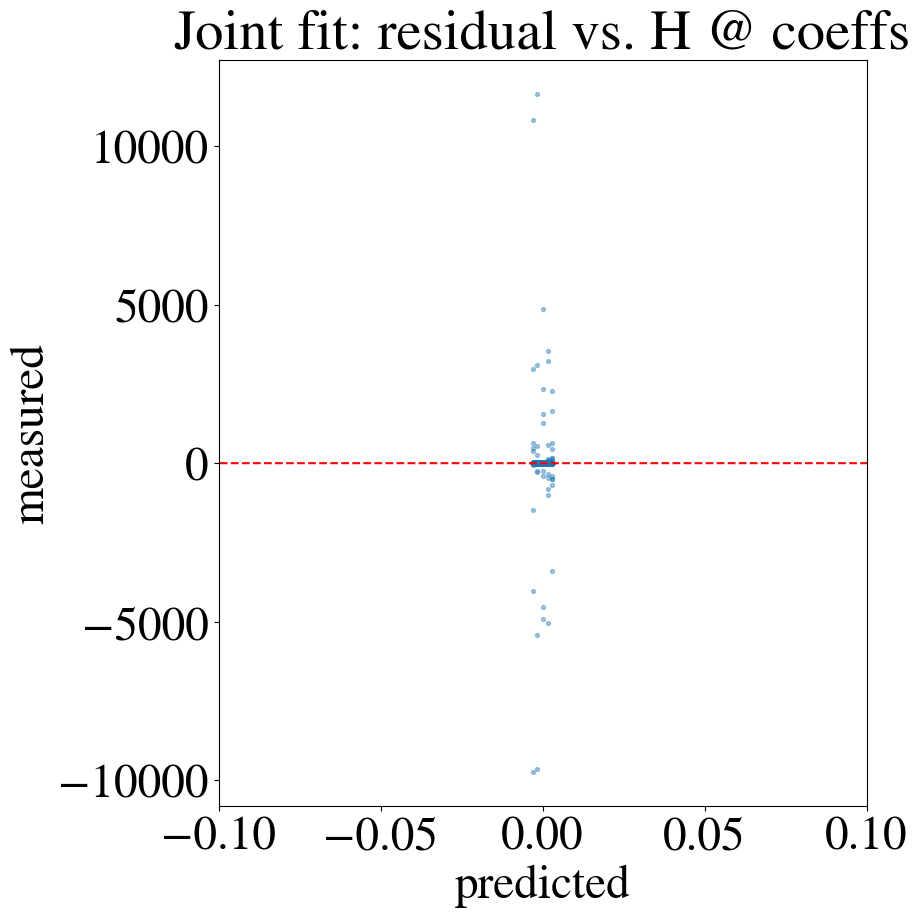

In [79]:
scale_goodness = fit_and_score(sys_modes_operator, res_flattened)
FIG = plot_fit(sys_modes_operator, res_flattened, scale_goodness[0])
plt.show()

Component errors saved, (6/10)


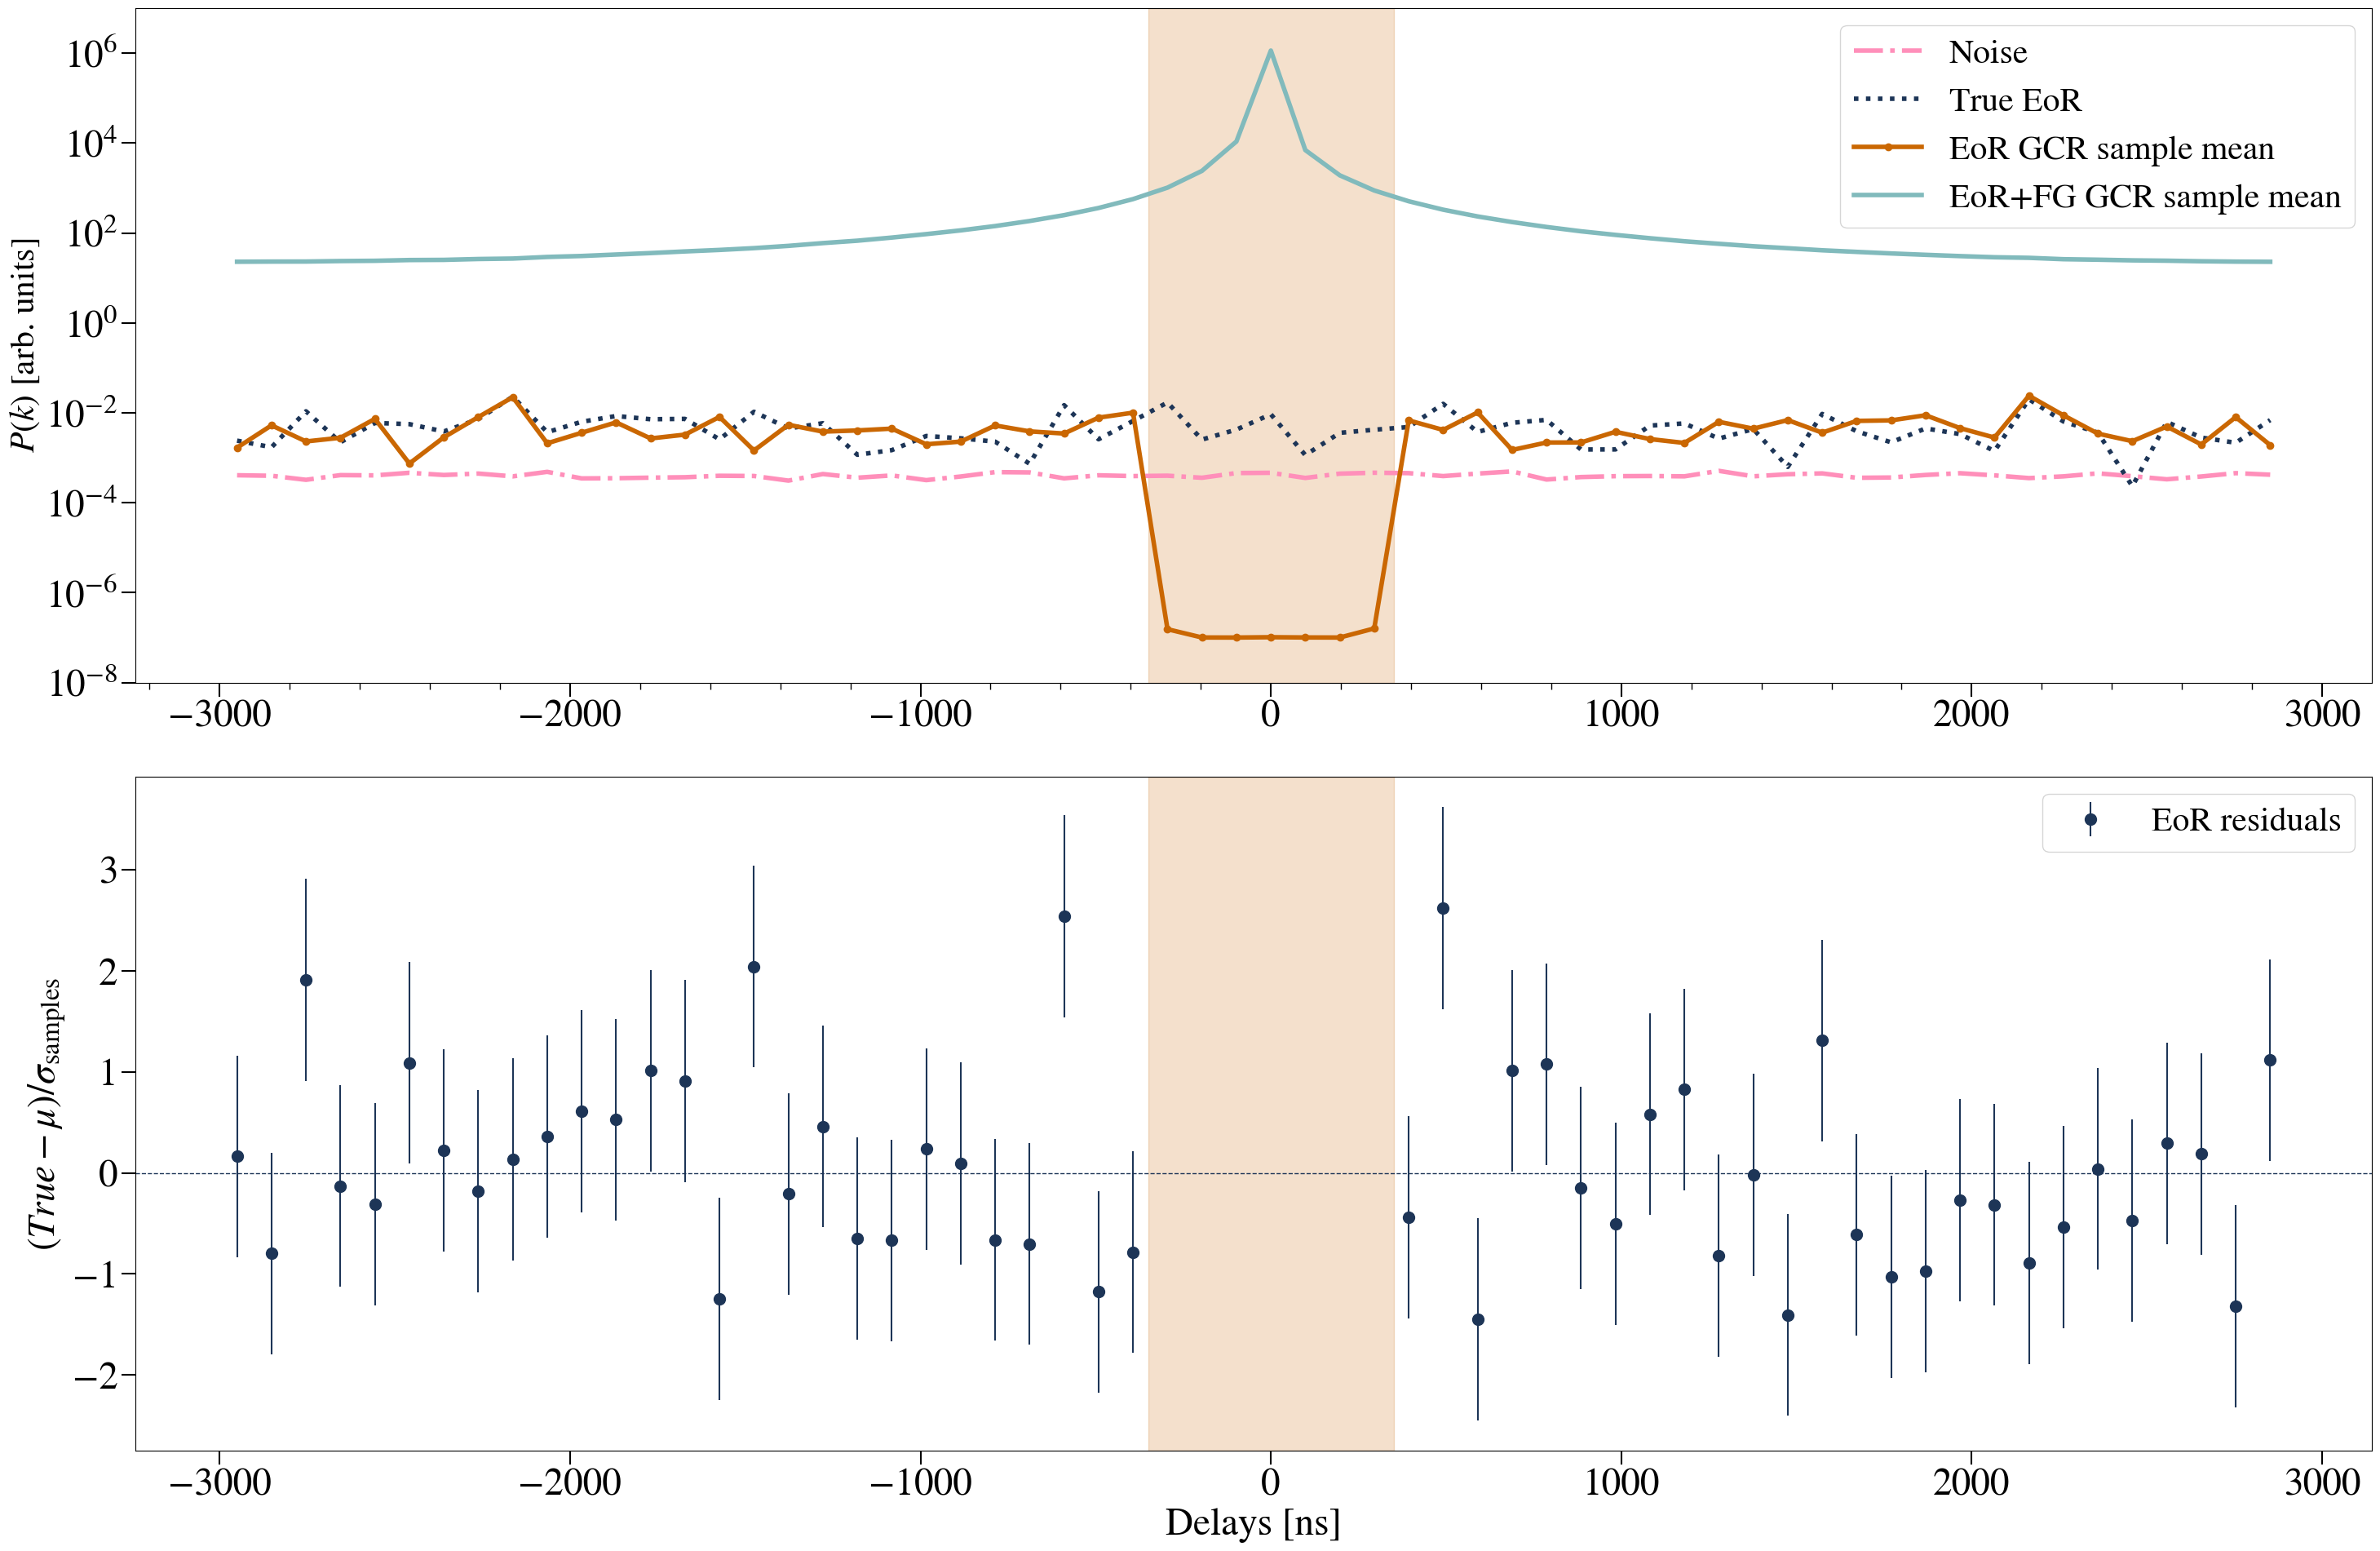

In [94]:
fig, axs = plt.subplots(2, 1, figsize=(30, 20))

data_arr_errs = [(eor_pspec_true - ps_sample) / np.std(ps_sample)]
plot_arr      = [d.mean(axis=0) for d in data_arr_errs]
fig_labels_err = ['True EoR', 'EoR GCR sample mean', 'EoR+FG GCR sample mean', 'Noise']

rm   = np.arange(27, 34)
keep = np.ones(len(plot_arr[0]), dtype=bool)
keep[rm] = False
yerr_bar = np.ones(len(eor_pspec_true))

# --------------- top plot ----------------
axs[0].set_yscale('log')
axs[0].plot(delays, n_pspec,             ls='-.', c=colors[-1], label=fig_labels_err[-1], lw=4)
axs[0].plot(delays, eor_pspec_true,      ls='dotted', c=colors[0], label=fig_labels_err[0], lw=4)
axs[0].plot(delays, ps_sample.mean(axis=0), marker='o', c=colors[1], label=fig_labels_err[1], lw=4)
axs[0].plot(delays, sky_pspec_avg,       c=colors[2], label=fig_labels_err[2], lw=4)
axs[0].legend(fontsize=30)
axs[0].set_ylim(1e-8, 1e7)
axs[0].axvspan(-350, 350, facecolor=colors[1], ec=colors[1], alpha=0.2, zorder=0.1)
axs[0].set_ylabel(r'$P(k)$ [arb. units]', fontsize=30)
axs[0].minorticks_on()
axs[0].tick_params(which='major', direction='out', length=12, width=1.5)
axs[0].tick_params(which='minor', direction='out', length=6,  width=1.0)


# --------------- bottom plot ----------------
pa  = plot_arr[0][keep]
da  = data_arr_errs[0][:, keep]
std = np.std(np.abs(da), axis=0)
axs[1].errorbar(
    delays[keep].value, pa, yerr=yerr_bar[keep],
    fmt='o', color=colors[0], label='EoR residuals', markersize=10,
)
axs[1].legend(fontsize=30)
axs[1].axhline(0, color=colors[0], linestyle='--', linewidth=1)
axs[1].axvspan(-350, 350, facecolor=colors[1], ec=colors[1], alpha=0.2, zorder=0.1)
axs[1].set_xlabel('Delays [ns]')
axs[1].set_ylabel(r'$(True - \mu)/ \sigma_\text{samples}$')
axs[1].minorticks_on()
axs[1].tick_params(which='major', direction='out', length=12, width=1.5)
axs[1].tick_params(which='minor', direction='out', length=0)  # hides minor ticks on bottom panel

plt.tight_layout()
# plt.savefig(fig_dir + '/errors_components.pdf', bbox_inches='tight', dpi=300)
print("Component errors saved, (6/10)")

## [NOT IN TEX / WIP]: Fractional errors by component – all cases

---
# Figure 6 (fig:corner_plots): Corner plot of b_sys (single case) → bsys_corner_plot.pdf

Corner plot of b_sys saved, (7/10)


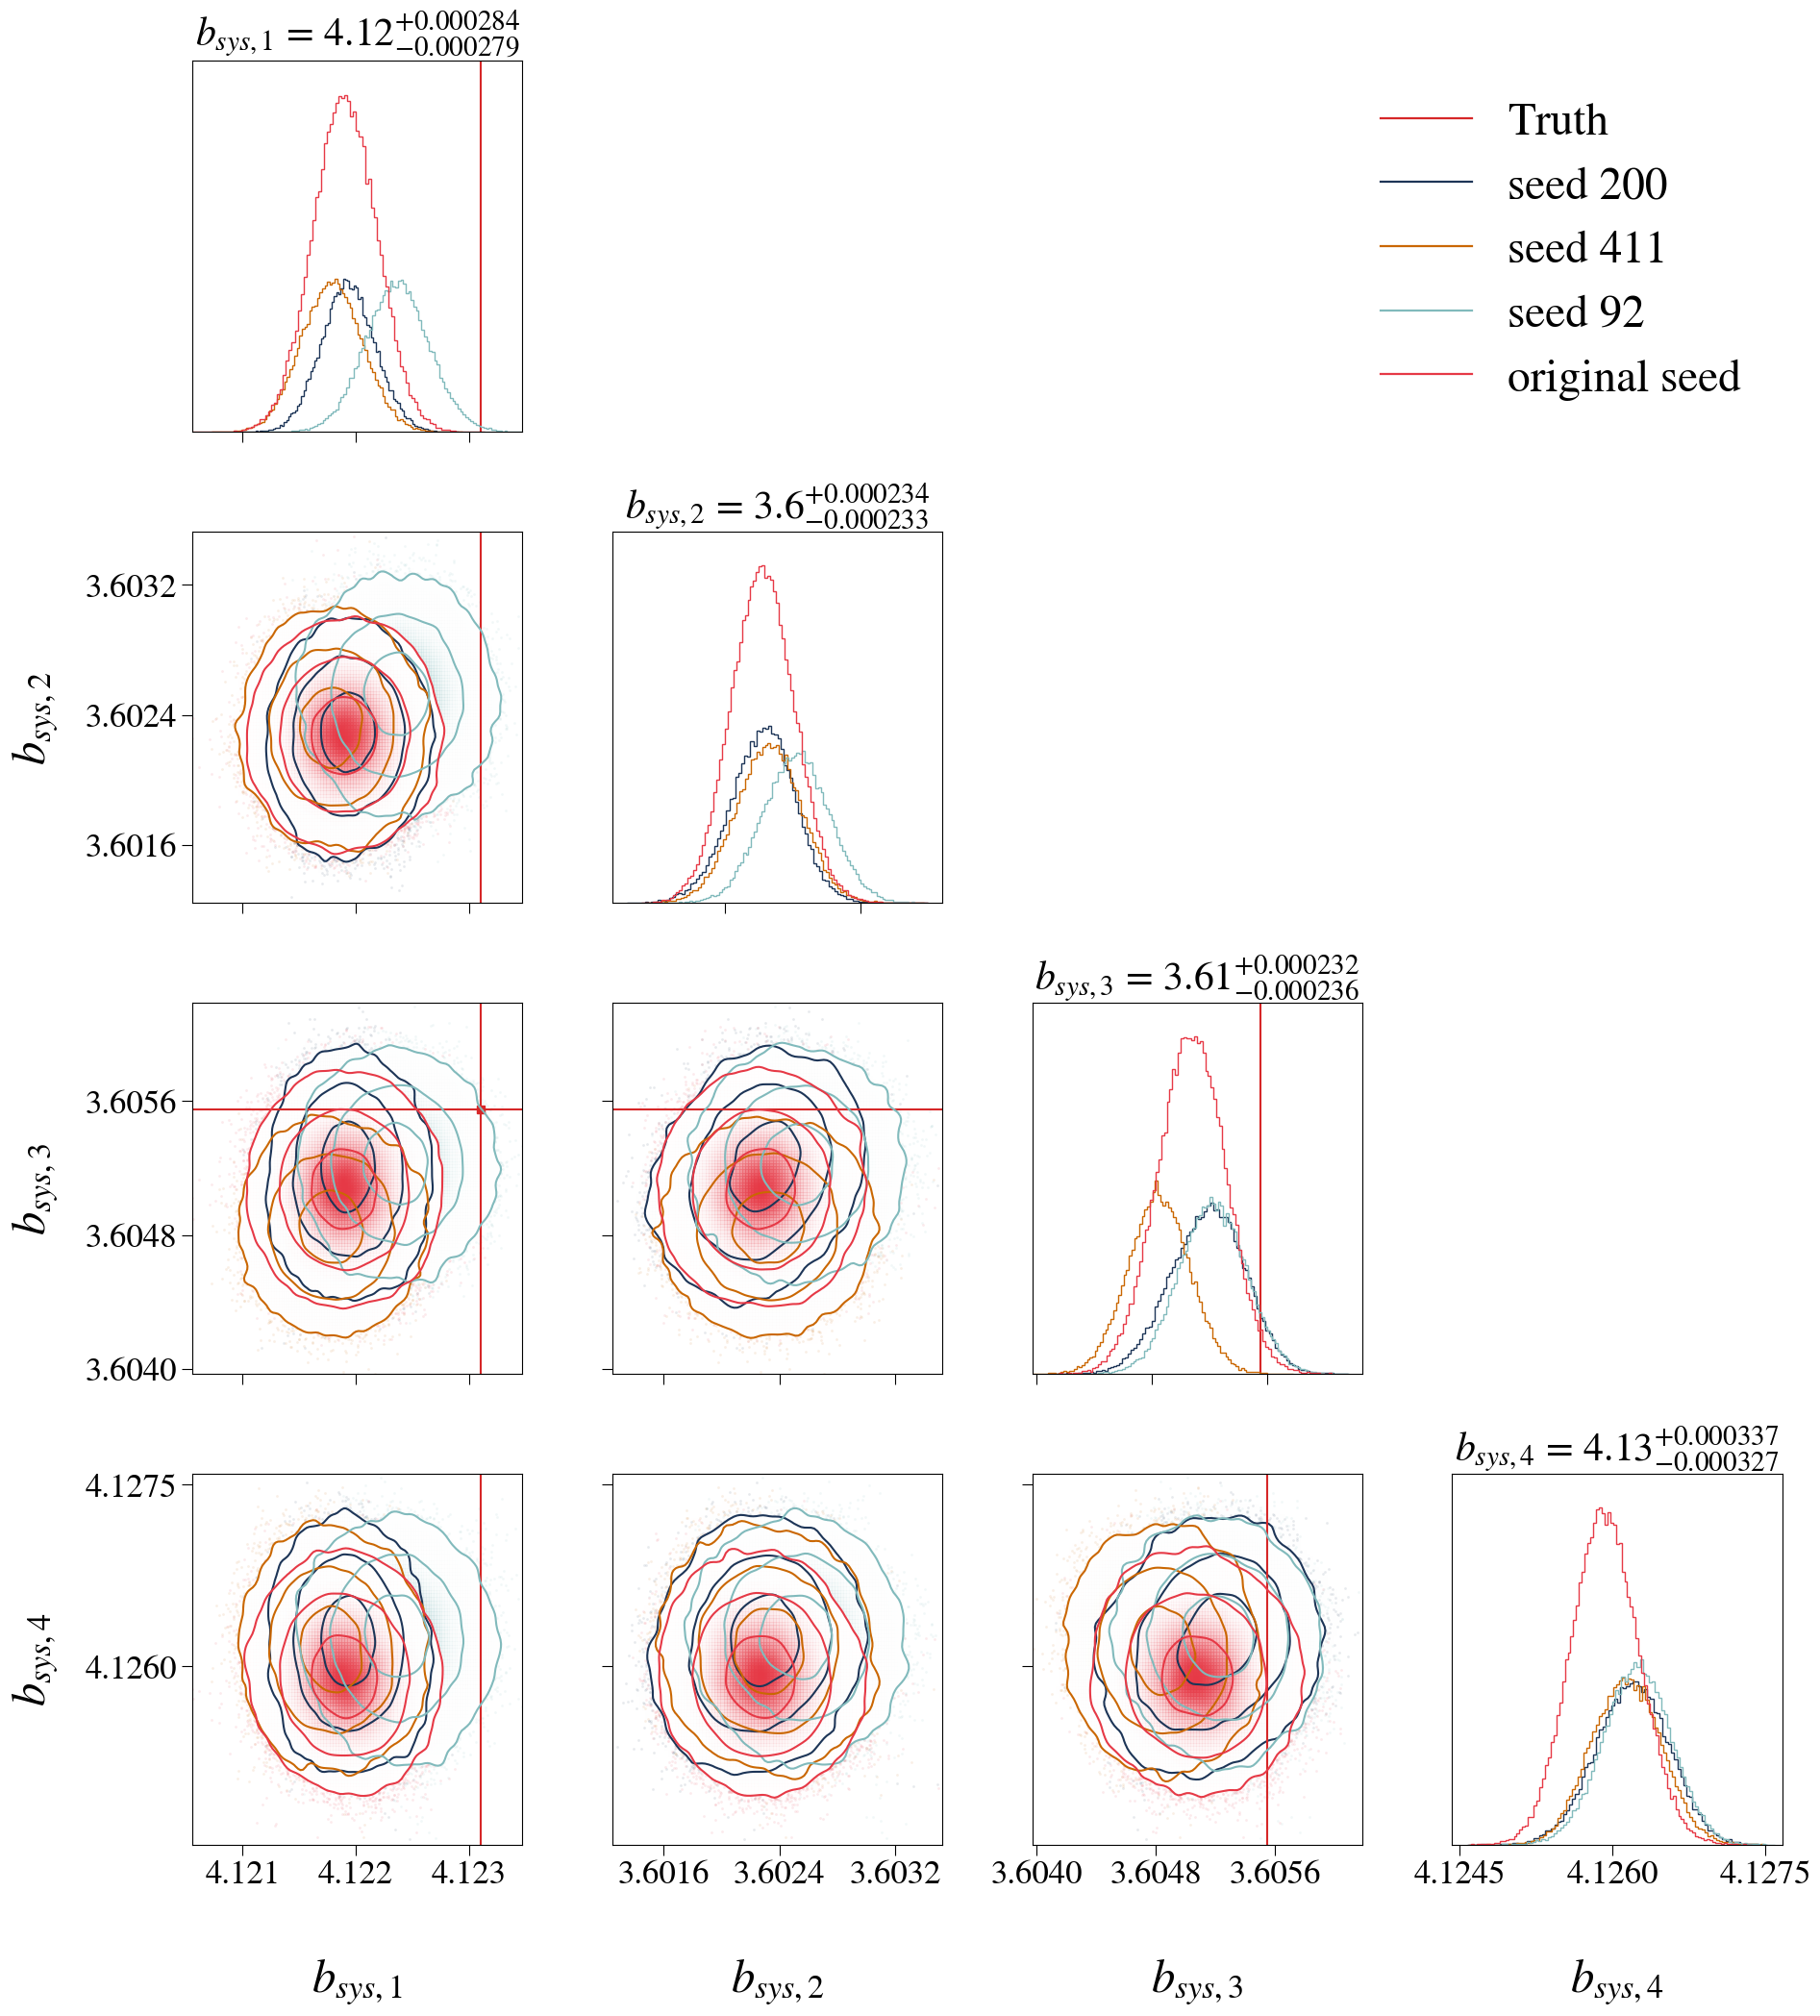

In [32]:
fig, ax = plt.subplots(4, 4, figsize=(20, 22))

for a in ax.flatten():
    a.tick_params(length=8)

i=0
for run_ver in run_version_arr:
    b_sys_i = np.load(result_dir + run_ver + '/b-sys.npy')
    corner_plot(
        np.abs(b_sys_i),
        truths=np.abs(sys_amps_true) if i==0 else None,
        labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'],
        color=colors[i],
        fig=fig,
        nsigma=3,
        title = None,
        case_label=case_labels[i]
    )
    i=i+1
# plt.savefig(fig_dir + '/bsys_corner_plot.pdf', bbox_inches='tight', dpi=100)
print("Corner plot of b_sys saved, (7/10)")

---
# [NOT IN TEX / WIP]: Systematics fractional error (single case)

---
# Figure 7 (fig:dps): Delay power spectra (all cases) → delay_power_spectrum_combined.pdf

Mean fractional error for Case seed 200: 0.6208815730604677
Mean fractional error for Case seed 411: 0.48793516023516886
Mean fractional error for Case seed 92: 0.4384875768102973
Mean fractional error for Case original seed: 0.5067869337730068
Delay power spectra (all cases) saved, (8/10)


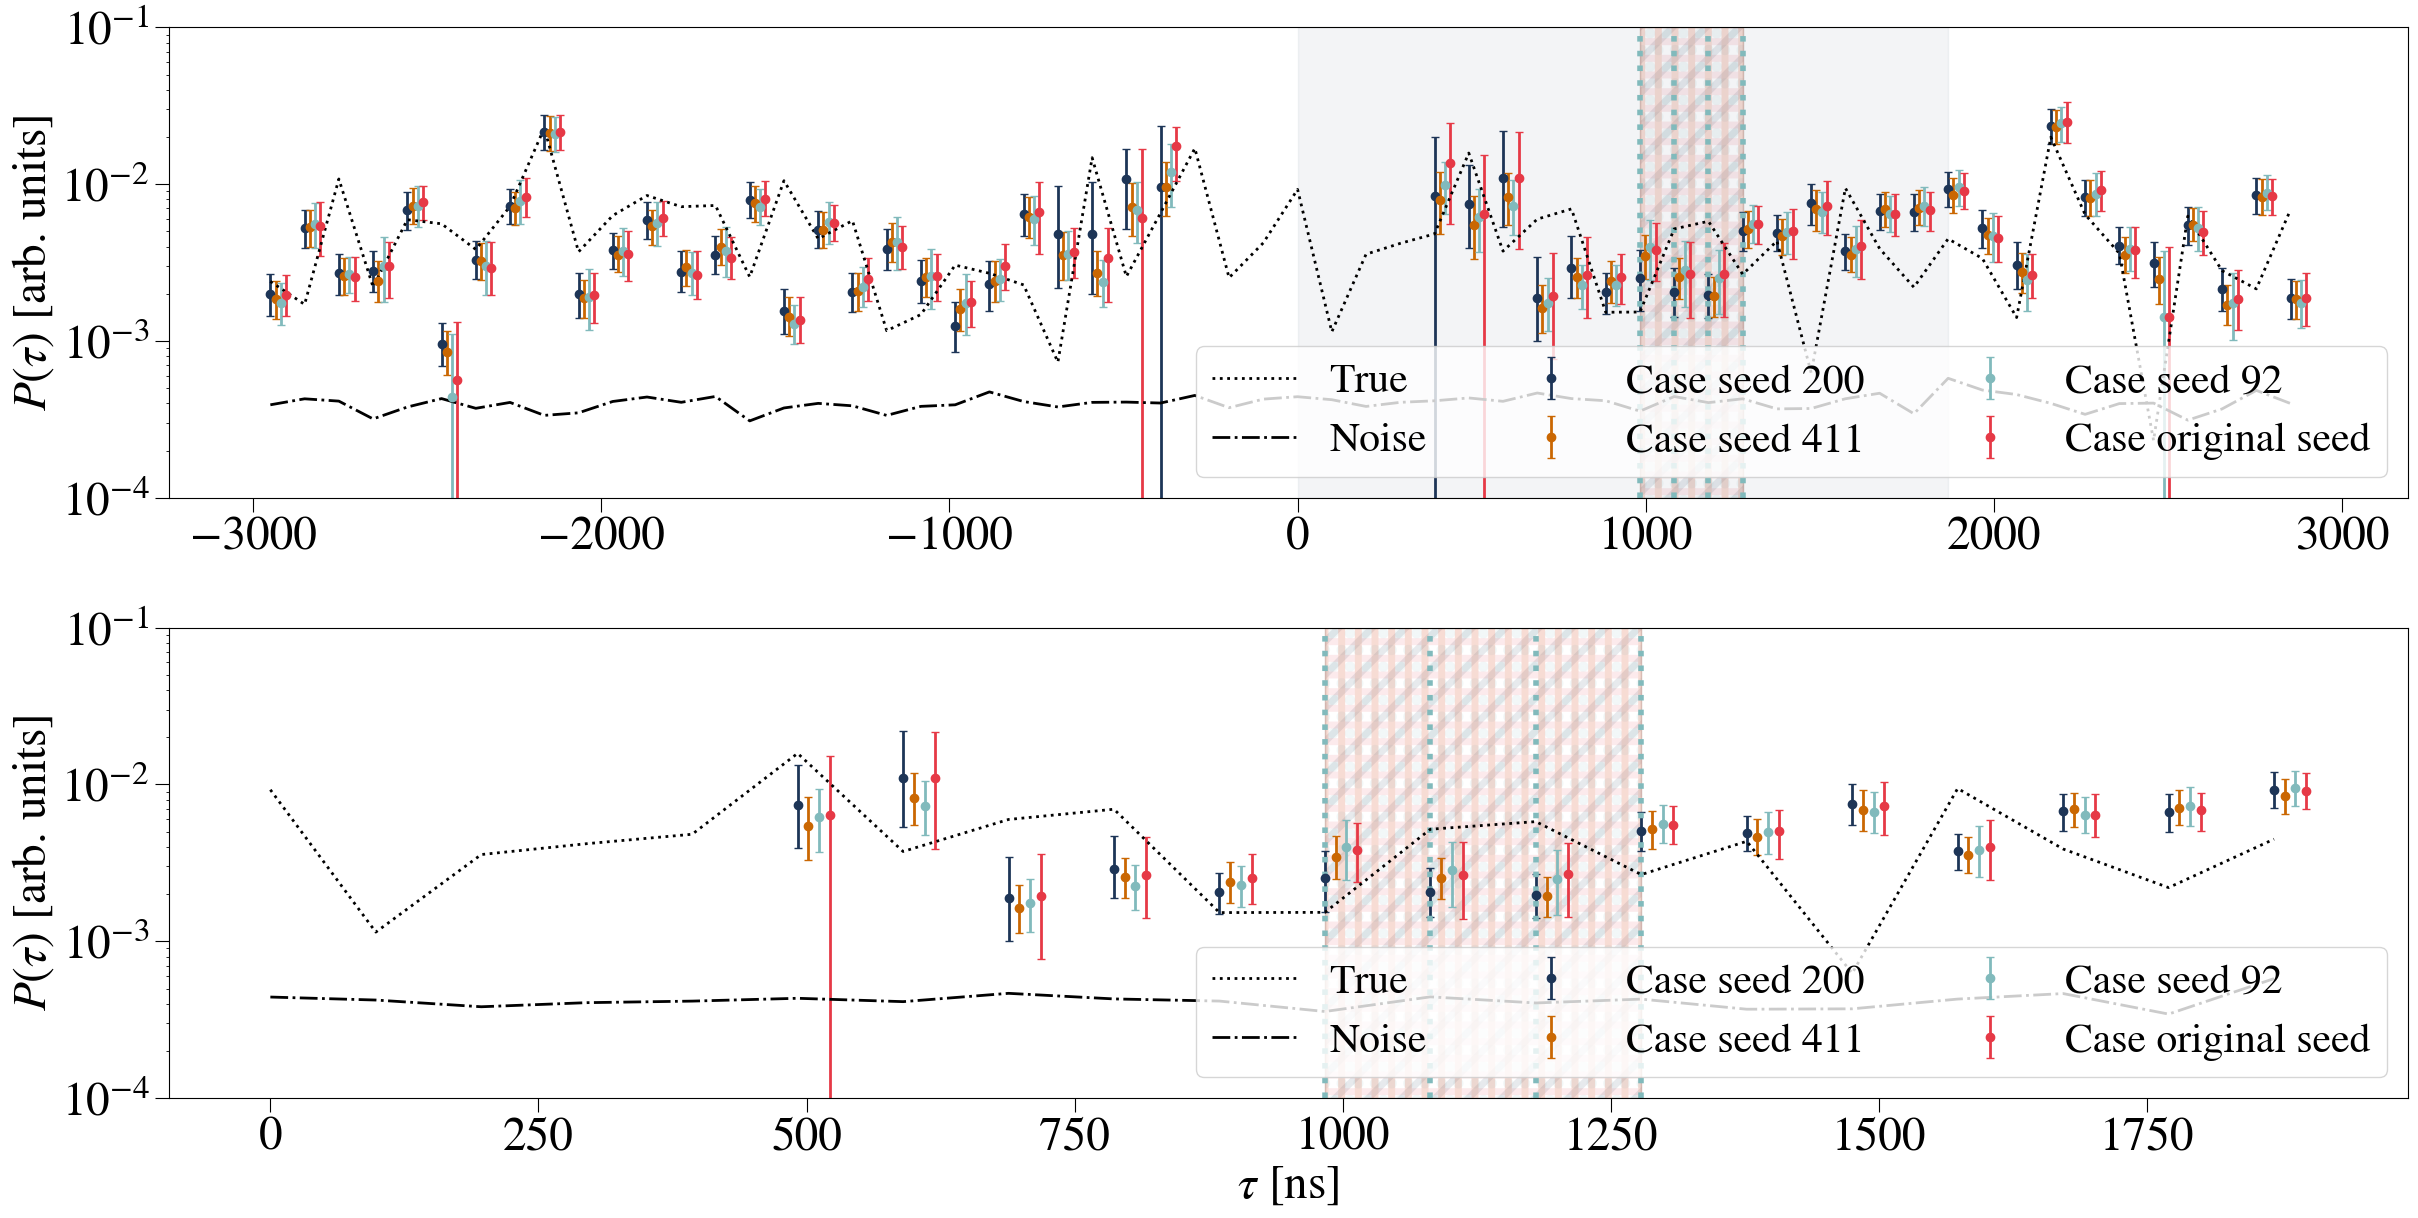

In [45]:
fig, ax = plt.subplots(2, 1, figsize=(25, 13))

# fig_labels_dps = ['I', 'II', 'III']
fig_labels_dps = case_labels
hatches = ['/', '|', '.', '+']

for i, run_version in enumerate(run_version_arr):
    eor_true_i = np.load(result_dir + run_version + '/eor_true.npy')
    ps_sample_i = np.load(result_dir + run_version + '/dps-eor.npy')
    ln_post_i   = np.load(result_dir + run_version + '/ln-post.npy')
    ps_true_i   = calc_ps(eor_true_i[:Ntimes, :Nfreqs])

    sys_delays = delays[np.unique(dl_inds[i]) + int(Nfreqs / 2)].value

    if Nburn > 0:
        ps_sample_i = ps_sample_i[Nburn:]
        ln_post_i   = ln_post_i[Nburn:]

    dps_pwm    = np.average(ps_sample_i, weights=ln_post_i, axis=0)
    percentile = conf_interval / 2 + 50
    dps_ubound = np.percentile(ps_sample_i, percentile,       axis=0)
    dps_lbound = np.percentile(ps_sample_i, 100 - percentile, axis=0)
    dps_err    = np.vstack((dps_pwm - dps_lbound, dps_ubound - dps_pwm))

    ax[0].errorbar(
        delays.value + i * 15, dps_pwm, yerr=np.abs(dps_err),
        color=colors[i], ls='', marker='o', elinewidth=2, capsize=3, label='Case ' + fig_labels_dps[i],
    )

    x0, x1 = np.min(sys_delays), np.max(sys_delays)
    ax[0].axvspan(x0, x1, facecolor='none', ec=colors[i], hatch=hatches[i], hatch_linewidth=5, alpha=0.1, zorder=0.1)
    ax[1].axvspan(x0, x1, facecolor='none', ec=colors[i], hatch=hatches[i], hatch_linewidth=5, alpha=0.1, zorder=0.1)

    if i == 2:
        for dl in sys_delays:
            ax[0].axvline(dl, ls='dotted', c=colors[i], lw=4)
            ax[1].axvline(dl, ls='dotted', c=colors[i], lw=4)

    ax[1].errorbar(
        delays[35:50].value + i * 10, dps_pwm[35:50], yerr=np.abs(dps_err[:, 35:50]),
        color=colors[i], ls='', marker='o', elinewidth=2, capsize=3, label='Case ' + fig_labels_dps[i],
    )
    print("Mean fractional error for Case {}: {}".format(fig_labels_dps[i], np.mean((dps_pwm - ps_true_i) / ps_true_i)))

ps_true_ref = calc_ps(np.load(result_dir + run_version_arr[0] + '/eor_true.npy')[:Ntimes, :Nfreqs])

ax[0].plot(delays, ps_true_ref, 'k:', label='True', lw=2)
ax[0].plot(delays, calc_ps(n.T), 'k', ls='-.', label='Noise', lw=2)
ax[0].legend(loc='lower right', ncol=3, fontsize=30)
ax[0].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[0].set_ylim(1e-4, 1e-1)
ax[0].set_yscale('log')
ax[0].axvspan(delays[30].value, delays[49].value, facecolor=colors[0], ec=colors[0],alpha=0.05, zorder=0.1)

ax[1].plot(delays[30:50], ps_true_ref[30:50], 'k:', label='True', lw=2)
ax[1].plot(delays[30:50], calc_ps(n.T)[30:50], 'k', ls='-.', label='Noise', lw=2)
ax[1].legend(loc='lower right', ncol=3, fontsize=30)
ax[1].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[1].set_xlabel(r'$\tau$ [ns]')
ax[1].axhline(0, ls='dotted')
ax[1].set_ylim(1e-4, 1e-1)
ax[1].set_yscale('log')

for a in ax.flatten():
    a.tick_params(length=10)
fig.tight_layout()
# plt.savefig(fig_dir + '/delay_power_spectrum_combined.pdf', bbox_inches='tight', dpi=300)
print("Delay power spectra (all cases) saved, (8/10)")

---
# Table 1: ESS and autocorrelation time

In [46]:
print("-------ESS TABLES------- \n")
for run_version in run_version_arr:
    print('Case:', run_version)
    b_sys = np.load(result_dir + run_version + '/b-sys.npy')
    taus  = emcee.autocorr.integrated_time(b_sys, c=5, tol=50, quiet=True, has_walkers=False)
    ess   = Niter / taus
    print('\n Taus: {}\nEss:{}\n'.format(taus, ess))

The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 1000;
tau: [3992.76835846 3597.12420394 3324.91749564  203.35864138]


-------ESS TABLES------- 

Case: seed_200

 Taus: [3992.76835846 3597.12420394 3324.91749564  203.35864138]
Ess:[ 12.52263981  13.89999265  15.03796713 245.87103681]

Case: seed_411

 Taus: [19.89677338 14.53119459 12.37543459 29.83715622]
Ess:[2512.97027079 3440.87333598 4040.26215227 1675.76291873]

Case: seed_92

 Taus: [21.72413059 14.66417733 13.49936001 31.96317779]
Ess:[2301.58807963 3409.66962456 3703.87929196 1564.30003065]

Case: high_dl_fr_0

 Taus: [22.32236011 15.9370257  14.24851621 28.16567808]
Ess:[2239.90652166 3137.34826872 3509.13732212 1775.21023457]



---
# Figure 8 (fig:fg_sys_corr): FG–systematics Pearson correlation (all cases) → fg_sys_corr.pdf

FG-systematics pearson correlation saved, (9/10)


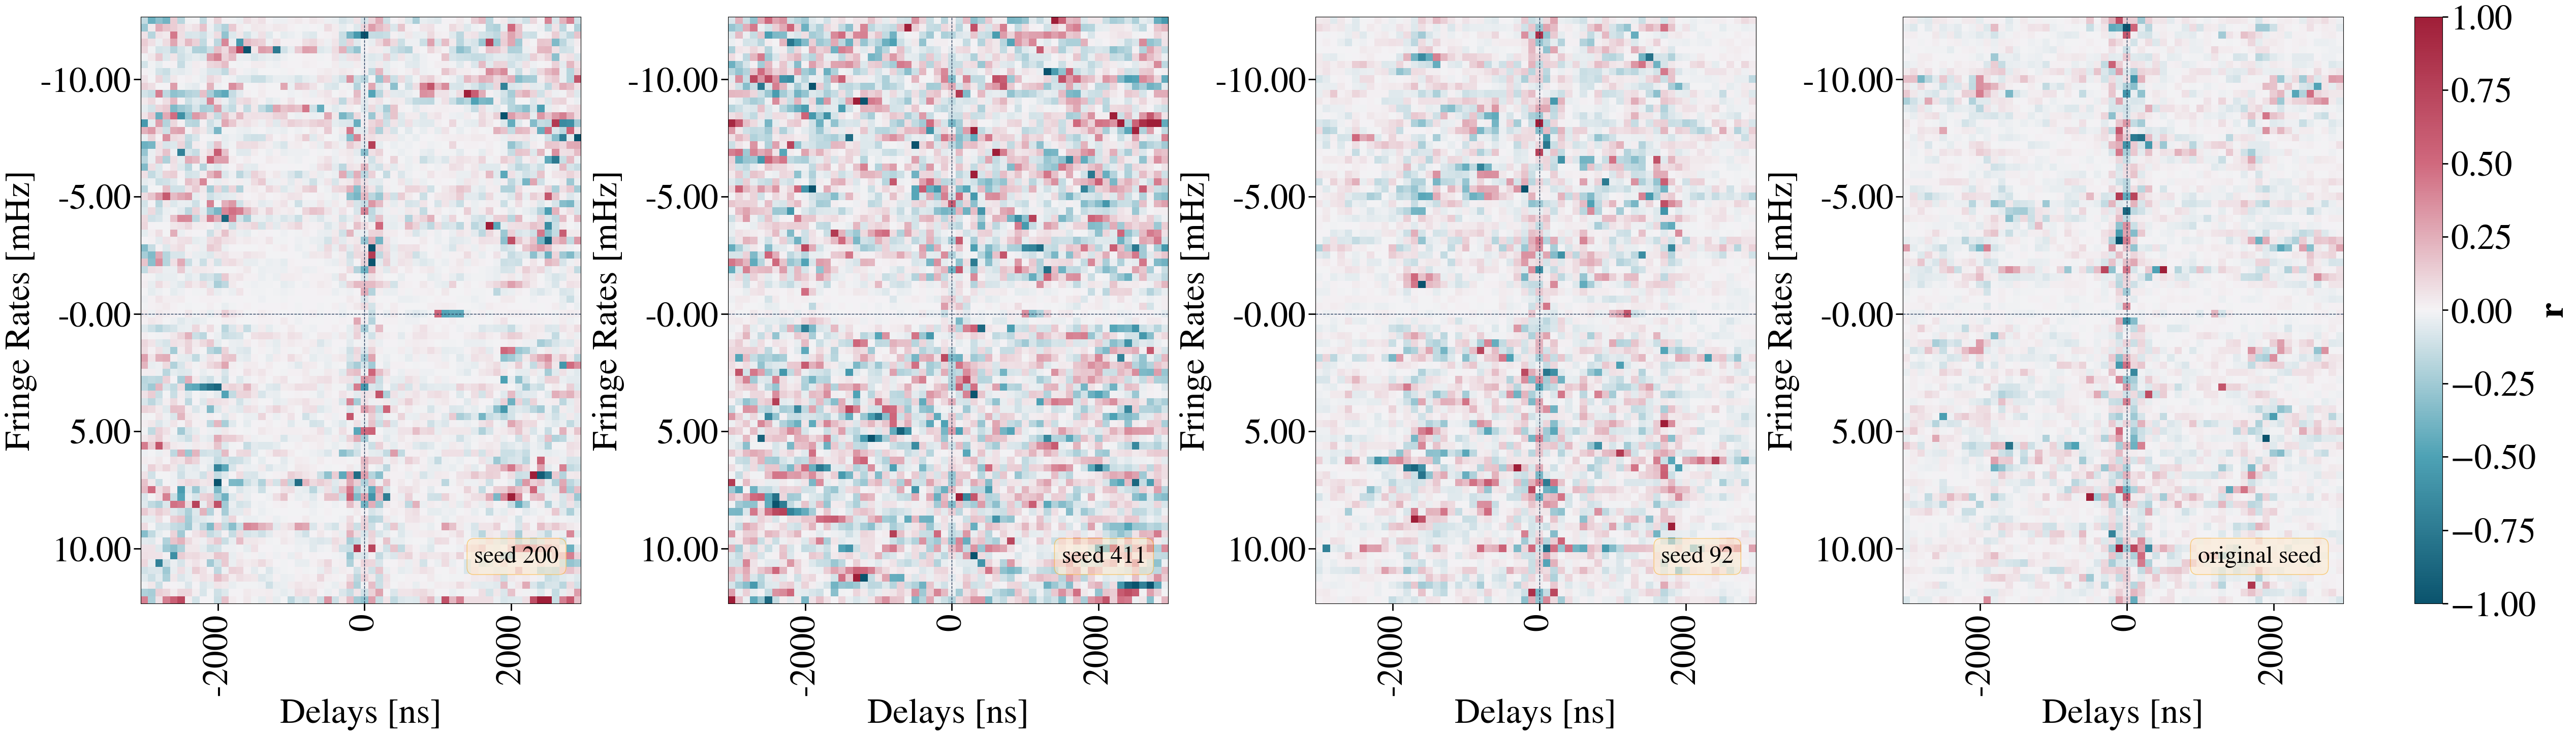

In [48]:
fig = plt.figure(figsize=(15 * case_num, 15))
axs = ImageGrid(
    fig, 111,
    nrows_ncols=(1, case_num),
    axes_pad=0.5,
    share_all=True,
    label_mode='all',
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

fig_labels_corr = case_labels
for i in range(case_num):
    im = axs[i].imshow(corr_maps[i].real, cmap=paper_map, vmin=-1, vmax=1)
    axs[i].text(0.95, 0.07, fig_labels_corr[i], bbox=bbox,
                transform=axs[i].transAxes, horizontalalignment='right')

cbar = axs.cbar_axes[0].colorbar(im)
cbar.set_label(r'$\mathbf{r}$', size=50)
cbar.ax.tick_params(labelsize=50, length=8, width=2, colors='black')

for ax in axs:
    ax.set_xlabel('Delays [ns]', fontsize=50)
    ax.set_ylabel('Fringe Rates [mHz]', fontsize=50)
    ax.tick_params(direction='out', length=8, width=2, colors='black', size=10, labelsize=50)
    ax.set_xticks(xticklocs_dl, labels=xticklabels_dl, rotation=90)
    ax.set_yticks(yticklocs_fr, labels=yticklabels_fr)

for a in axs:
    a.axvline(dl_zero, color=colors[0], linestyle='--', linewidth=1)
    a.axhline(fr_zero, color=colors[0], linestyle='--', linewidth=1)
    
# plt.savefig(fig_dir + '/fg_sys_corr.pdf', bbox_inches='tight', dpi=300)
print("FG-systematics pearson correlation saved, (9/10)")

# Correlation matrix

Correlation matrix saved, (10/10)


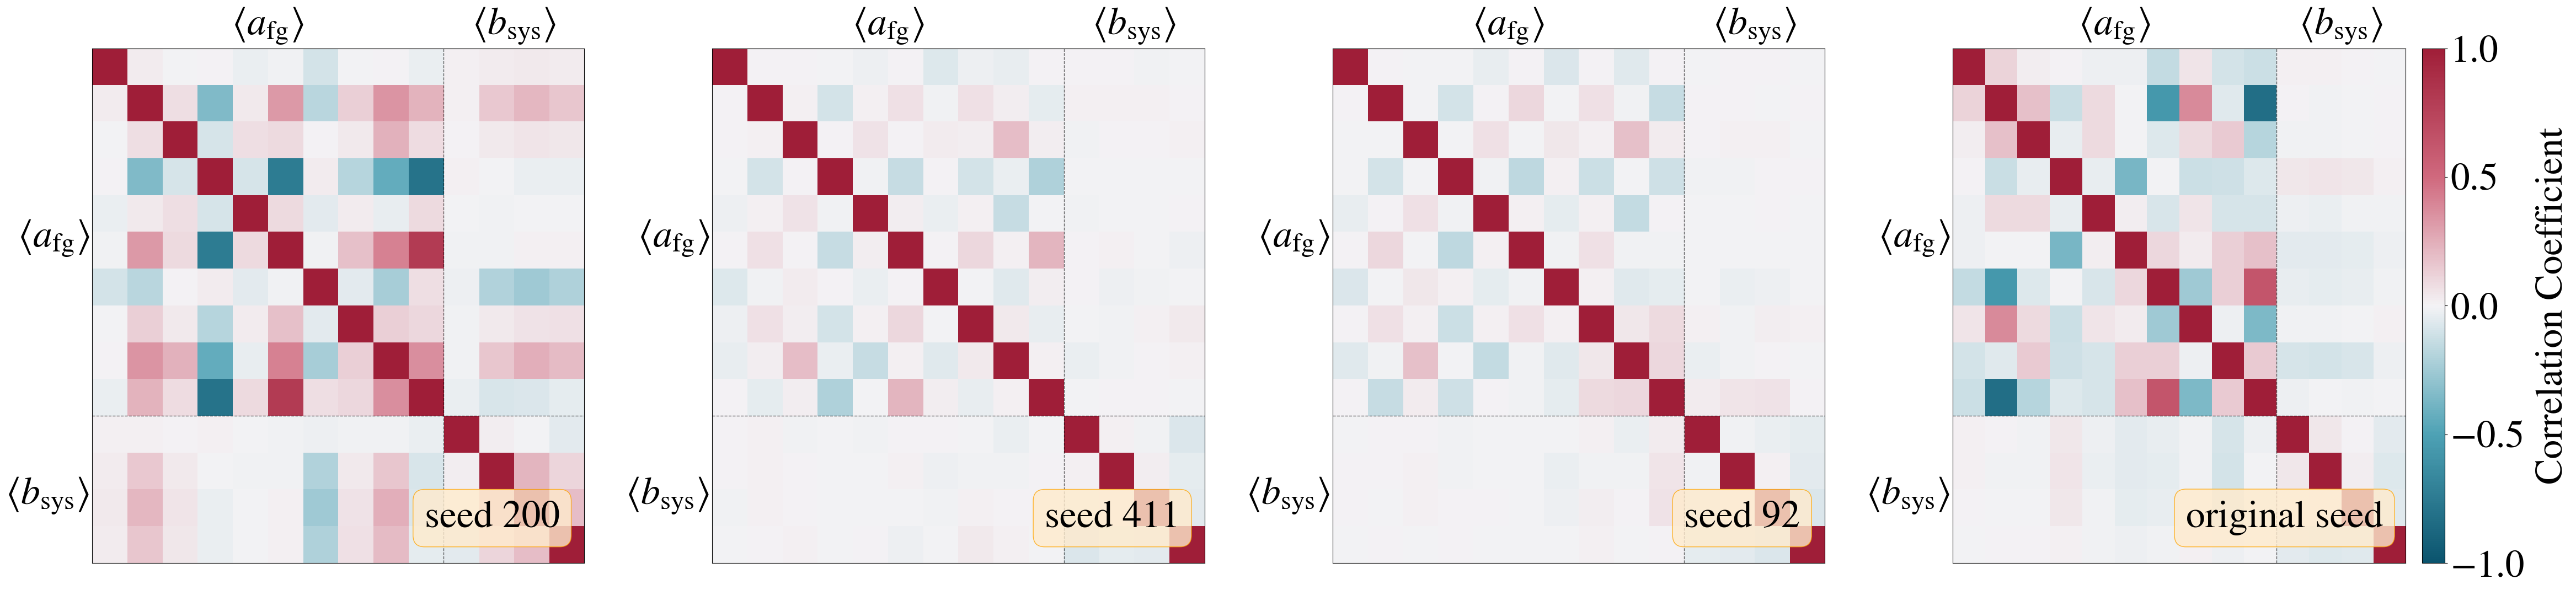

In [49]:
# Figure 9 (fig:corr): Foreground/systematics parameter correlation matrices → correlation_matrix.pdf

def plot_correlation_matrix(corr, ax, param_names, param_sizes, fontsize=40, cmap="RdBu"):
    """
    Plot a formatted correlation matrix into a given Axes object.

    Parameters
    ----------
    corr : np.ndarray, shape (N, N)
        Correlation matrix.
    ax : matplotlib.axes.Axes
        Axes to plot into.
    param_names : list of str
        Parameter block names, e.g. ['EoR', 'Foregrounds', 'Systematics'].
    param_sizes : list of int
        Number of elements per parameter block, e.g. [4800, 12, 4].
    cmap : str
        Colormap. Default 'RdBu'.

    Returns
    -------
    im : AxesImage
        The image object (used externally for the shared colorbar).
    """
    im = ax.matshow(corr, cmap=cmap, vmin=-1, vmax=1, aspect="auto", interpolation="none")

    # --- Block dividing lines ---
    boundaries = np.cumsum(param_sizes)[:-1] - 0.5
    for b in boundaries:
        ax.axhline(b, color="k", linewidth=1.0, linestyle="--", alpha=0.6)
        ax.axvline(b, color="k", linewidth=1.0, linestyle="--", alpha=0.6)

    # --- Block centre positions for labels ---
    centres = []
    start = 0
    for size in param_sizes:
        centres.append(start + size / 2 - 0.5)
        start += size

    # --- Axis labels ---
    ax.set_xticks(centres)
    ax.set_xticklabels(
        [rf"$\langle {n} \rangle$" for n in param_names],
        fontsize=fontsize,
    )
    ax.set_yticks(centres)
    ax.set_yticklabels(
        [rf"$\langle {n} \rangle$" for n in param_names],
        fontsize=fontsize,
    )
    ax.tick_params(length=0)

    return im


# --- Usage ---
param_names  = [r'a_\text{fg}', r'b_\text{sys}']
param_sizes  = [10, 4]
test_case_labels = case_labels

fig, axes = plt.subplots(1, case_num, figsize=(12. * case_num, 12))
plt.rcParams.update({'font.size': 50})  # Set global font size for labels and ticks
for i, (ax, label) in enumerate(zip(axes, test_case_labels)):
    fg_amps_gcr = np.load(result_dir+run_version_arr[i]+'/fg-amps.npy')
    b_sys_gcr   = np.load(result_dir + run_version_arr[i] + '/b-sys.npy')

    fg_flat = np.abs(fg_amps_gcr[:Niter,-3,:]).reshape(Niter, -1)  # (10000, 4800)
    samples_all = np.concatenate([fg_flat, np.abs(b_sys_gcr[:Niter,:])], axis=1)  # (10000, 4816)
    cov = np.cov(samples_all, rowvar=False)  # (4816, 4816)
    corr = np.corrcoef(samples_all, rowvar=False)  # (4816
    
    im = plot_correlation_matrix(
        corr        = corr,
        ax          = ax,
        param_names = param_names,
        param_sizes = param_sizes,
        cmap        = paper_map,
        fontsize    = 50,
    )
    ax.text(0.95, 0.07, label, bbox=bbox_res, transform=ax.transAxes, horizontalalignment='right')

# --- Colorbar anchored exactly to the last axes ---
divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.3)
cbar = fig.colorbar(im, cax=cax,)
cbar.set_label(label="Correlation Coefficient", fontsize=50, labelpad=15)
cax.yaxis.label.set_size(50)
cax.tick_params(labelsize=50)

fig.tight_layout()
# plt.savefig(fig_dir + '/correlation_matrix.pdf', bbox_inches='tight', dpi=300)
print("Correlation matrix saved, (10/10)")

# Time elapsed

In [68]:
elapsed = time.time() - _notebook_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)
print(f"Total notebook runtime: {int(hours):02d}h {int(mins):02d}m {secs:.1f}s")

Total notebook runtime: 00h 53m 11.2s
